#I.Business Understanding

## 1.Xác định business problem, mục tiêu dự án, ML problem, target và success criteria


 1.1. Business Problem
Ngân hàng thực hiện các chiến dịch marketing qua điện thoại nhưng tỷ lệ khách hàng đăng ký **Term Deposit** thấp, dẫn đến lãng phí thời gian, nhân lực và chi phí marketing.

 1.2. Project Objective
Xây dựng hệ thống dự đoán khả năng khách hàng đăng ký Term Deposit để **ưu tiên nhóm khách hàng có tiềm năng cao**, từ đó tăng hiệu quả và tối ưu nguồn lực marketing.

 1.3. ML Problem
- **Learning type:** Supervised Learning
- **Problem type:** Binary Classification phân loại nhị phân
- **Input:** Thông tin khách hàng, tài chính và lịch sử marketing.
- **Output:** Xác suất khách hàng đăng ký Term Deposit.

1.4. Target
- **Target:** `y`
- `yes` → Khách hàng đăng ký Term Deposit → `1`
- `no` → Khách hàng không đăng ký → `0`

1.5. Success Criteria
 ML Metrics
- PR-AUC
- Precision
- Recall
- F1-score
- ROC-AUC

#II.Data Understanding

##2.Tổng quan dataset: số dòng/cột, datatype, numerical/categorical/binary, missing, unknown, duplicate

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
from scipy.io import arff
import os

# THAY ĐỔI ĐƯỜNG DẪN NÀY
file_path = '/content/drive/MyDrive/phpkIxskf.arff'

if os.path.exists(file_path):
    try:
        data, meta = arff.loadarff(file_path)
        df = pd.DataFrame(data)

        # Decode bytes strings if necessary
        for column in df.select_dtypes(include=['object']).columns:
            if df[column].apply(lambda x: isinstance(x, bytes)).any():
                df[column] = df[column].str.decode('utf-8')

        # Mapping columns to English names
        column_mapping = {
            'V1': 'age',
            'V2': 'job',
            'V3': 'marital',
            'V4': 'education',
            'V5': 'default',
            'V6': 'balance',
            'V7': 'housing',
            'V8': 'loan',
            'V9': 'contact',
            'V10': 'day',
            'V11': 'month',
            'V12': 'duration',
            'V13': 'campaign',
            'V14': 'pdays',
            'V15': 'previous',
            'V16': 'poutcome',
            'Class': 'y'
        }

        df = df.rename(columns=column_mapping)
        print("Columns renamed successfully!")
        display(df.head())

        # Save to CSV
        csv_output = 'converted_data.csv'
        df.to_csv(csv_output, index=False)
        print(f"CSV file saved at: {csv_output}")

    except Exception as e:
        print(f"Error reading file: {e}")
else:
    print("File not found. Please check the path again.")

Columns renamed successfully!


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58.0,management,married,tertiary,no,2143.0,yes,no,unknown,5.0,may,261.0,1.0,-1.0,0.0,unknown,1
1,44.0,technician,single,secondary,no,29.0,yes,no,unknown,5.0,may,151.0,1.0,-1.0,0.0,unknown,1
2,33.0,entrepreneur,married,secondary,no,2.0,yes,yes,unknown,5.0,may,76.0,1.0,-1.0,0.0,unknown,1
3,47.0,blue-collar,married,unknown,no,1506.0,yes,no,unknown,5.0,may,92.0,1.0,-1.0,0.0,unknown,1
4,33.0,unknown,single,unknown,no,1.0,no,no,unknown,5.0,may,198.0,1.0,-1.0,0.0,unknown,1


CSV file saved at: converted_data.csv


In [3]:
print("--- 5 dòng đầu tiên ---")
display(df.head(5))

print("\n--- 5 dòng cuối cùng ---")
display(df.tail(5))

print("\n--- 5 dòng ngẫu nhiên ---")
display(df.sample(5))

--- 5 dòng đầu tiên ---


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58.0,management,married,tertiary,no,2143.0,yes,no,unknown,5.0,may,261.0,1.0,-1.0,0.0,unknown,1
1,44.0,technician,single,secondary,no,29.0,yes,no,unknown,5.0,may,151.0,1.0,-1.0,0.0,unknown,1
2,33.0,entrepreneur,married,secondary,no,2.0,yes,yes,unknown,5.0,may,76.0,1.0,-1.0,0.0,unknown,1
3,47.0,blue-collar,married,unknown,no,1506.0,yes,no,unknown,5.0,may,92.0,1.0,-1.0,0.0,unknown,1
4,33.0,unknown,single,unknown,no,1.0,no,no,unknown,5.0,may,198.0,1.0,-1.0,0.0,unknown,1



--- 5 dòng cuối cùng ---


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
45206,51.0,technician,married,tertiary,no,825.0,no,no,cellular,17.0,nov,977.0,3.0,-1.0,0.0,unknown,2
45207,71.0,retired,divorced,primary,no,1729.0,no,no,cellular,17.0,nov,456.0,2.0,-1.0,0.0,unknown,2
45208,72.0,retired,married,secondary,no,5715.0,no,no,cellular,17.0,nov,1127.0,5.0,184.0,3.0,success,2
45209,57.0,blue-collar,married,secondary,no,668.0,no,no,telephone,17.0,nov,508.0,4.0,-1.0,0.0,unknown,1
45210,37.0,entrepreneur,married,secondary,no,2971.0,no,no,cellular,17.0,nov,361.0,2.0,188.0,11.0,other,1



--- 5 dòng ngẫu nhiên ---


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
20295,55.0,blue-collar,married,primary,no,1512.0,no,no,cellular,11.0,aug,262.0,4.0,-1.0,0.0,unknown,1
23392,36.0,services,married,secondary,no,84.0,no,no,cellular,27.0,aug,206.0,3.0,-1.0,0.0,unknown,1
31098,59.0,management,married,tertiary,no,1831.0,no,no,cellular,17.0,feb,122.0,1.0,92.0,1.0,failure,1
39978,31.0,technician,single,tertiary,no,882.0,no,no,cellular,3.0,jun,411.0,1.0,-1.0,0.0,unknown,2
1977,38.0,self-employed,married,secondary,no,138.0,no,no,unknown,9.0,may,182.0,3.0,-1.0,0.0,unknown,1


1 age: Tuổi của khách hàng

2	job	: Loại công việc/nghề nghiệp của khách hàng

3	marital:	Tình trạng hôn nhân của khách hàng

4	education:	Trình độ học vấn của khách hàng

5	default:	Cho biết khách hàng có tín dụng bị vỡ nợ hay không

6	balance:	Số dư trung bình hàng năm trong tài khoản của khách hàng, tính bằng Euro

7	housing:	Cho biết khách hàng có khoản vay mua nhà hay không

8	loan:	Cho biết khách hàng có khoản vay cá nhân hay không

9	contact:	Loại hình liên lạc được sử dụng trong lần liên hệ gần nhất của chiến dịch hiện tại

10	day	:Ngày trong tháng của lần liên hệ gần nhất

11	month:	Tháng trong năm của lần liên hệ gần nhất

12	duration:	Thời lượng của lần liên hệ cuối cùng, tính bằng giây

13	campaign:	Số lần liên hệ đã thực hiện với khách hàng trong chiến dịch hiện tại, bao gồm cả lần liên hệ cuối cùng

14	pdays:	Số ngày kể từ lần cuối khách hàng được liên hệ trong một chiến dịch trước đó; -1 nghĩa là chưa từng được liên hệ trước đó

15	previous:	Số lần khách hàng đã được liên hệ trước chiến dịch hiện tại

16	poutcome:	Kết quả của chiến dịch marketing trước đó

17	y	:Cho biết khách hàng có đăng ký tiền gửi có kỳ hạn hay không

In [4]:
print(f"Số dòng: {df.shape[0]}")
print(f"Số cột: {df.shape[1]}")

print("\n--- Thông tin kiểu dữ liệu ---")
display(df.info())


print("\n--- Kiểm tra các giá trị 'unknown' trong các cột categorical ---")
for col in df.select_dtypes(include=['object']).columns:
    unknown_count = (df[col] == 'unknown').sum()
    if unknown_count > 0:
        print(f"{col}: {unknown_count} giá trị 'unknown'")

print("\n--- Kiểm tra dòng bị lặp (Duplicates) ---")
duplicates = df.duplicated().sum()
print(f"Số dòng bị lặp: {duplicates}")

Số dòng: 45211
Số cột: 17

--- Thông tin kiểu dữ liệu ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   age        45211 non-null  float64
 1   job        45211 non-null  object 
 2   marital    45211 non-null  object 
 3   education  45211 non-null  object 
 4   default    45211 non-null  object 
 5   balance    45211 non-null  float64
 6   housing    45211 non-null  object 
 7   loan       45211 non-null  object 
 8   contact    45211 non-null  object 
 9   day        45211 non-null  float64
 10  month      45211 non-null  object 
 11  duration   45211 non-null  float64
 12  campaign   45211 non-null  float64
 13  pdays      45211 non-null  float64
 14  previous   45211 non-null  float64
 15  poutcome   45211 non-null  object 
 16  y          45211 non-null  object 
dtypes: float64(7), object(10)
memory usage: 5.9+ MB


None


--- Kiểm tra các giá trị 'unknown' trong các cột categorical ---
job: 288 giá trị 'unknown'
education: 1857 giá trị 'unknown'
contact: 13020 giá trị 'unknown'
poutcome: 36959 giá trị 'unknown'

--- Kiểm tra dòng bị lặp (Duplicates) ---
Số dòng bị lặp: 0


insight:có 7 giá trị đinh lượng 9 giá trị định tính

có 4 biến job ,education,contact,poutcome có giá trị unknown nhiều

không có giá trị nào trùng lặp thì có thể thấy dữ liệu trên nhiều đối tượng

---



In [5]:
print("--- Thống kê mô tả cho các biến số (Numerical) ---")
display(df.describe())

print("\n--- Thống kê mô tả cho các biến phân loại (Categorical) ---")
display(df.describe(include=['object']))

--- Thống kê mô tả cho các biến số (Numerical) ---


,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000



--- Thống kê mô tả cho các biến phân loại (Categorical) ---


,job,marital,education,default,housing,loan,contact,month,poutcome,y
count,45211,45211,45211,45211,45211,45211,45211,45211,45211,45211
unique,12,3,4,2,2,2,3,12,4,2
top,blue-collar,married,secondary,no,yes,no,cellular,may,unknown,1
freq,9732,27214,23202,44396,25130,37967,29285,13766,36959,39922


insight:các biến định lượng thấy được sự phân bố tương đối của từng biến

các biến định tính thấy được số lượng các giá trị của từng biến và sự phân bố các biến định lượng

## 3.Univariate EDA: Phân tích đơn biến


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Thiết lập phong cách cho biểu đồ
sns.set(style="whitegrid")

# Lấy danh sách các cột số và cột phân loại
num_cols = df.select_dtypes(include=['float64', 'int64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

print(f"Các cột định lượng: {list(num_cols)}")
print(f"Các cột định tính: {list(cat_cols)}")

Các cột định lượng: ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']
Các cột định tính: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome', 'y']


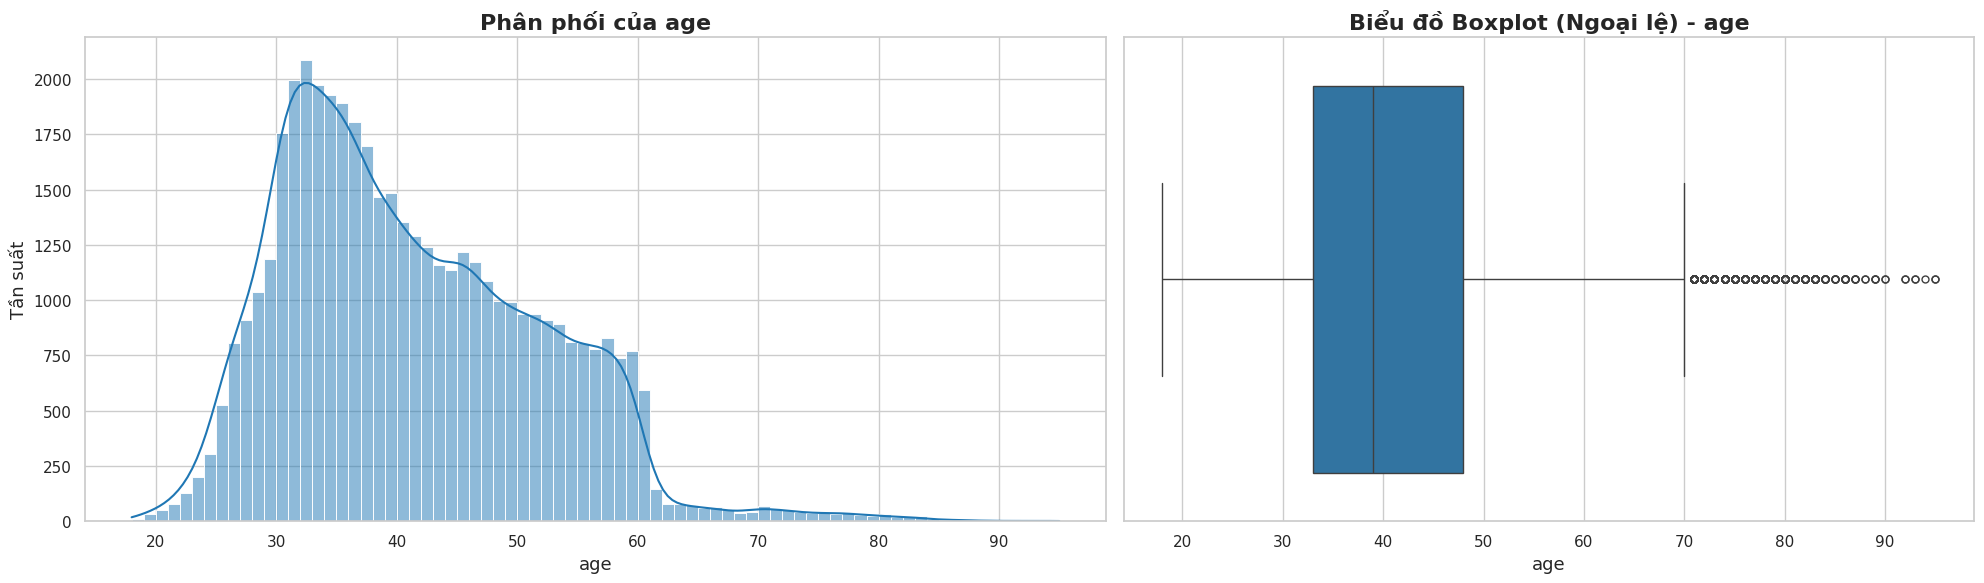

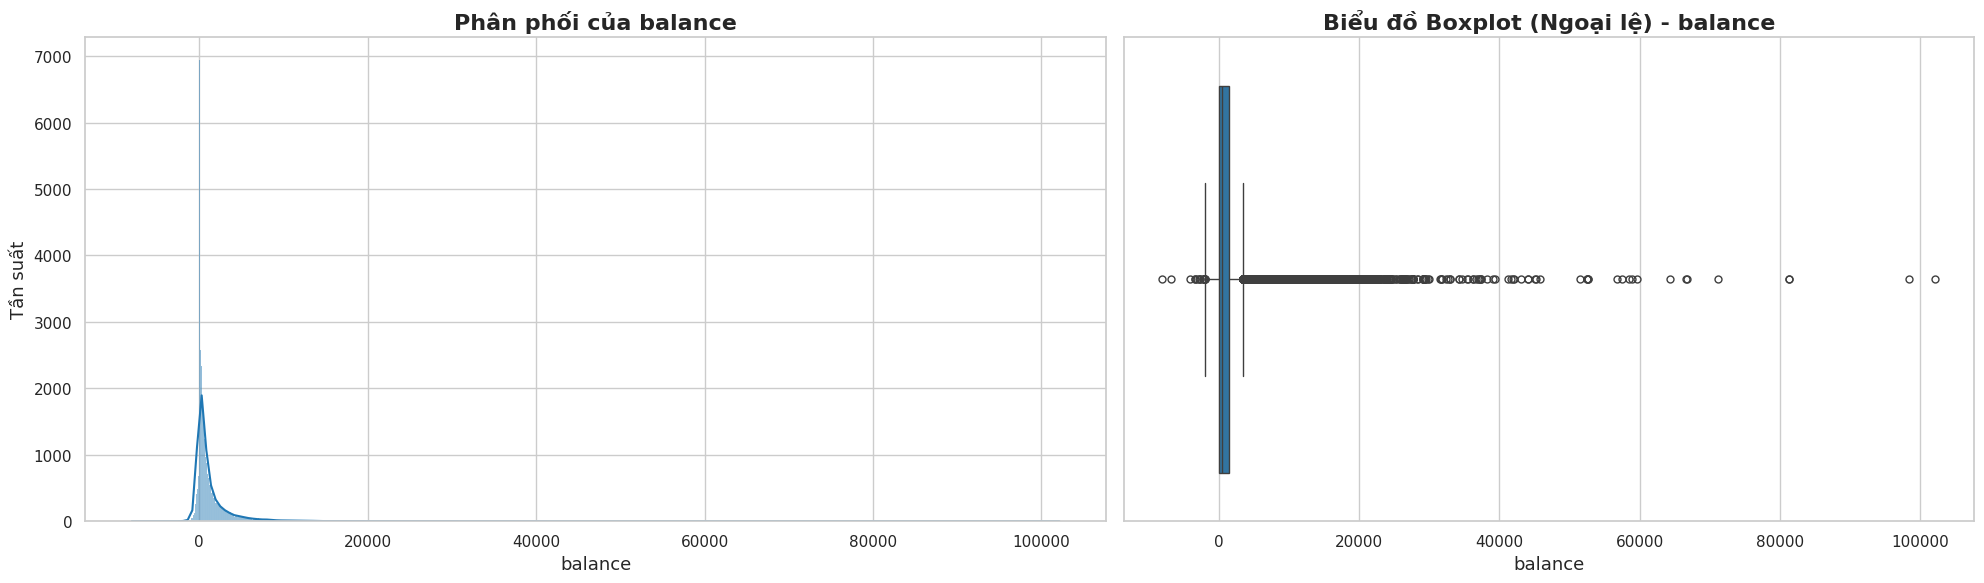

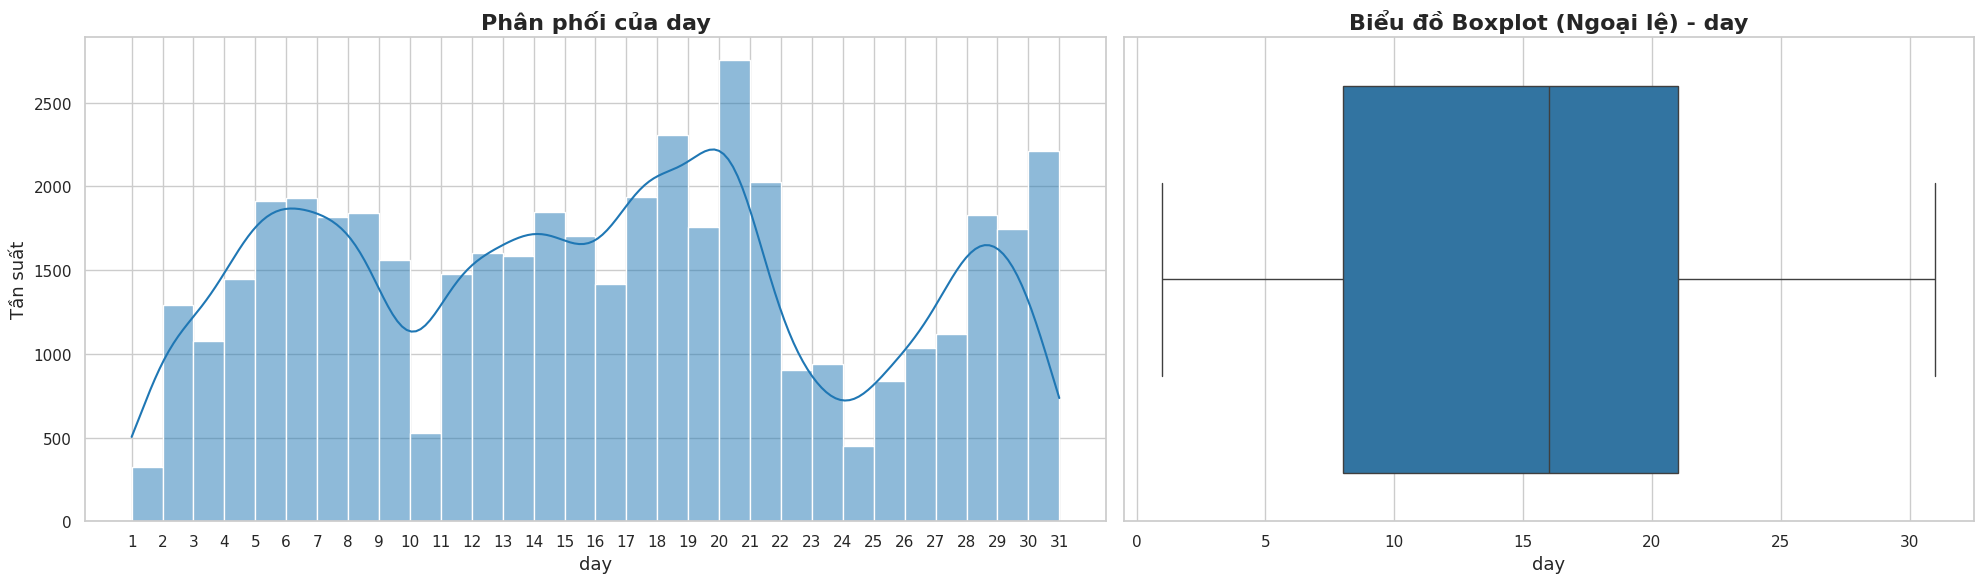

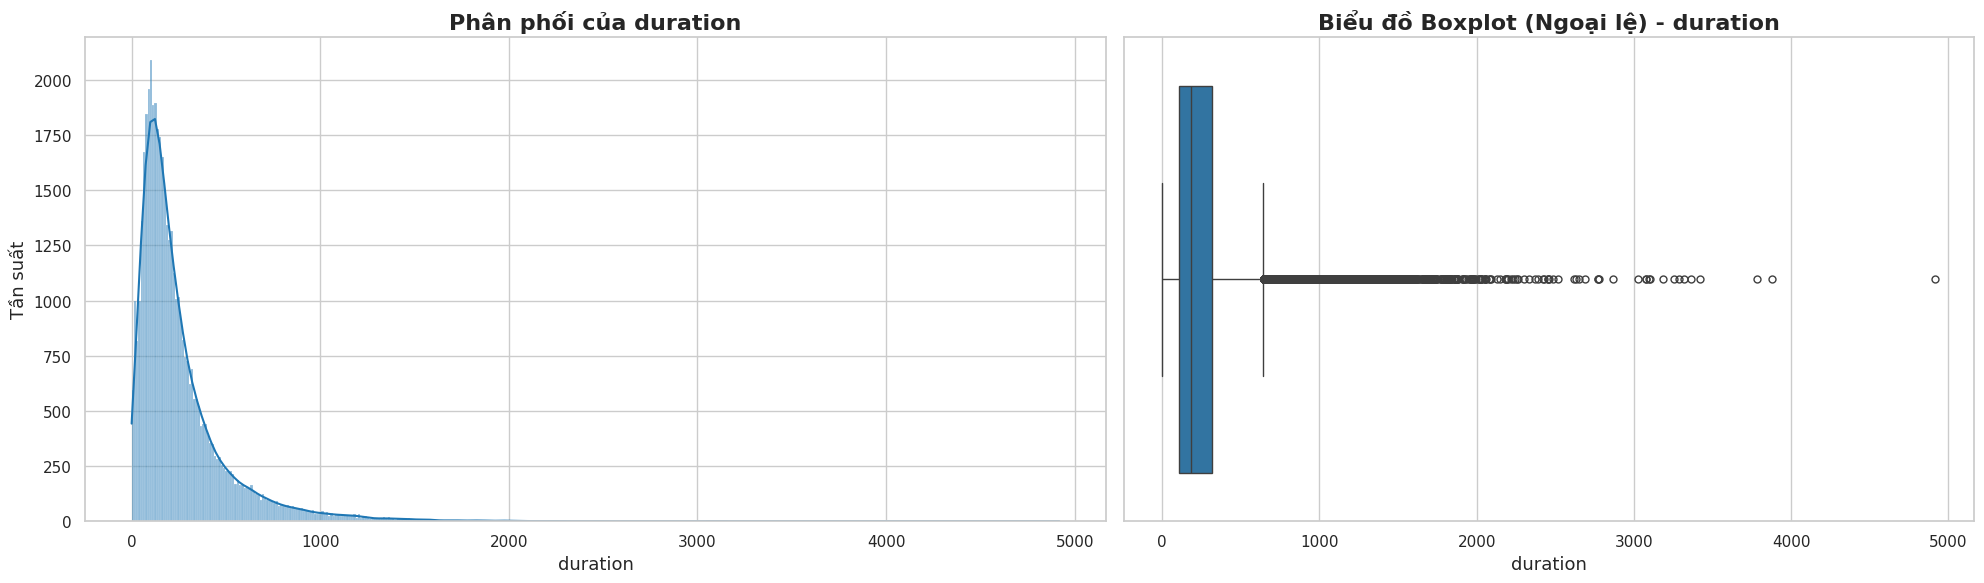

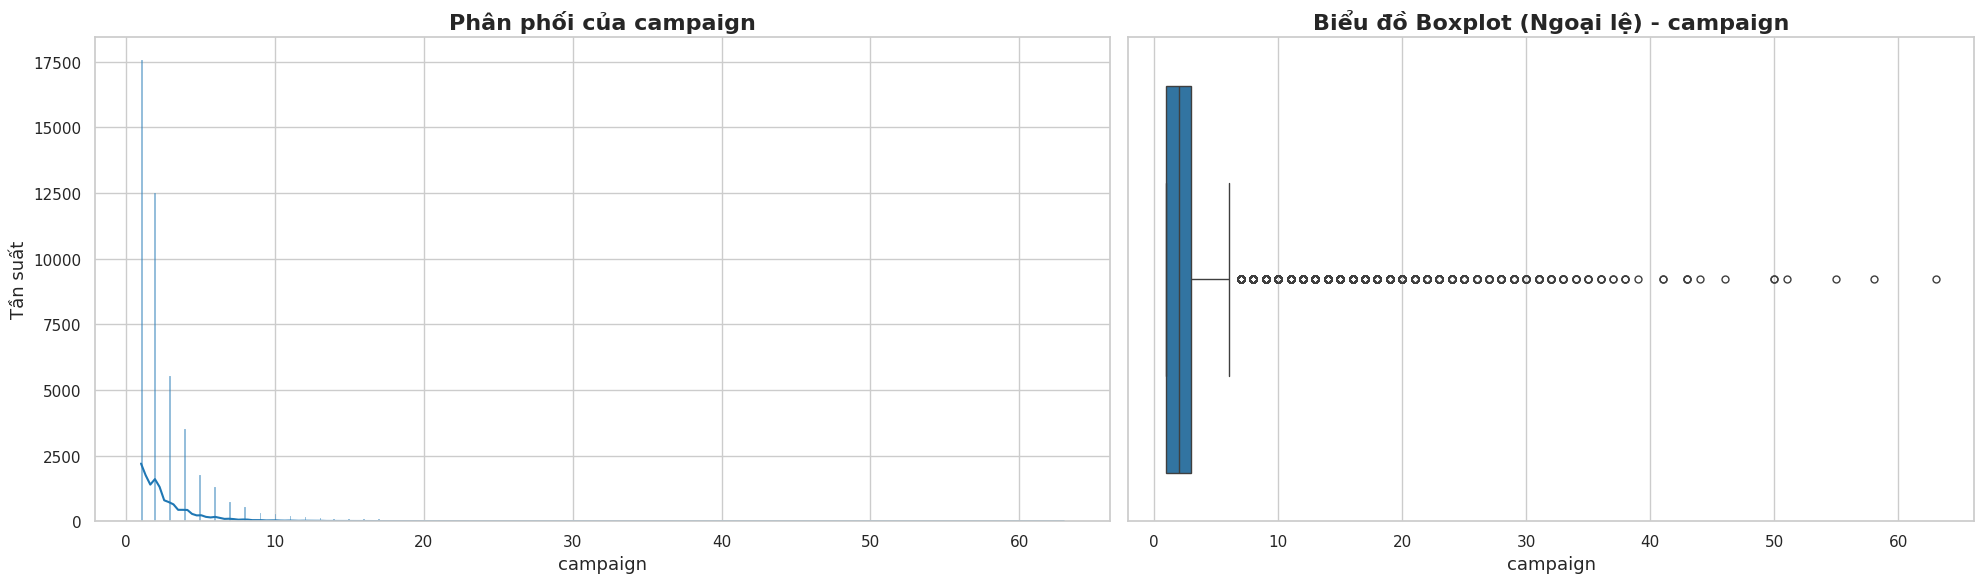

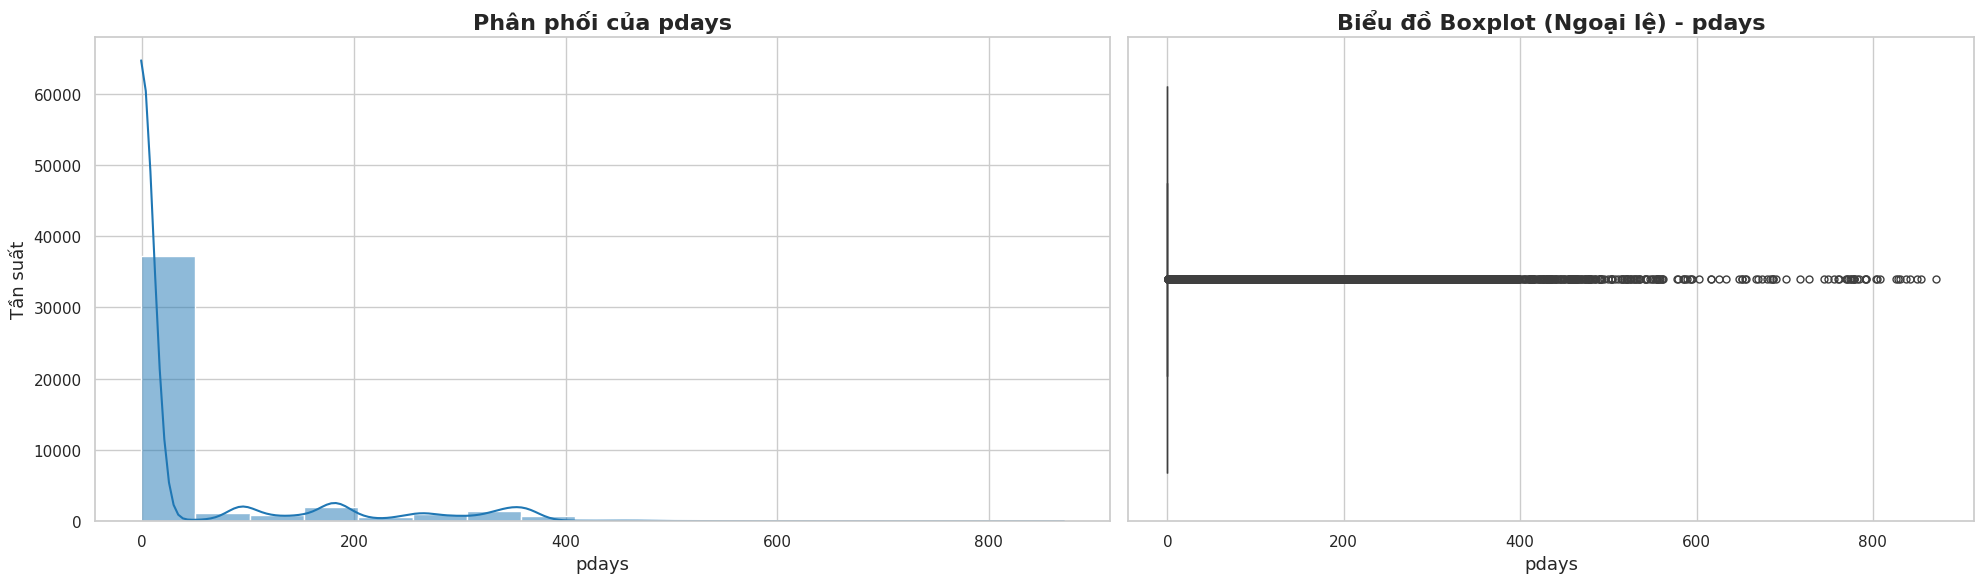

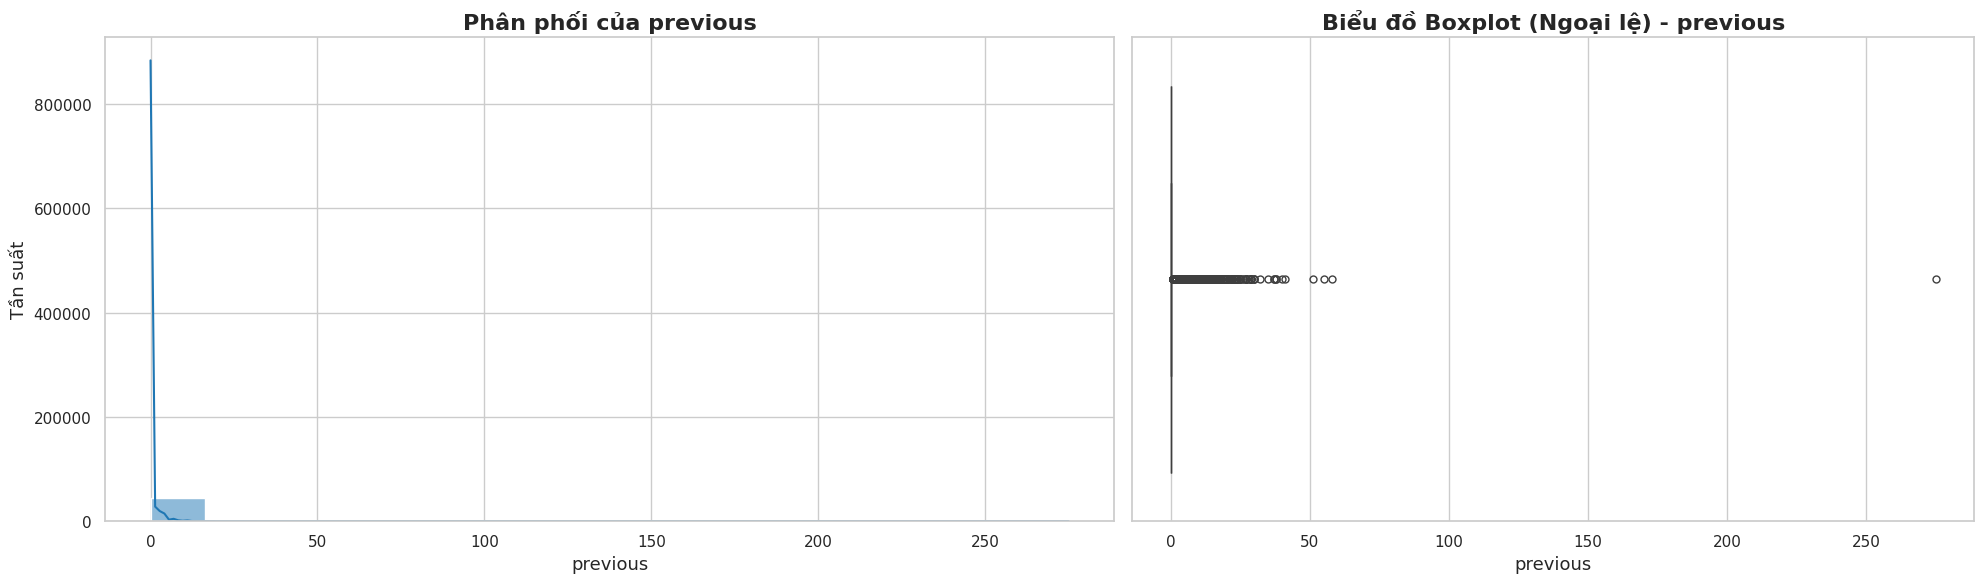

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

# 3.1 Trực quan hóa biến định lượng (Numerical) với kích thước lớn lấp đầy không gian
for col in num_cols:
    # Thiết lập figsize lớn (20, 6) để các biểu đồ chiếm trọn chiều ngang notebook
    fig, axes = plt.subplots(1, 2, figsize=(20, 6), gridspec_kw={'width_ratios': [1.2, 1]})

    # Histogram + KDE (Biểu đồ phân phối)
    # Sử dụng binwidth=1 cho 'day' và 'age' để lấp đầy khoảng trống vì đây là các giá trị rời rạc
    if col in ['day', 'age']:
        sns.histplot(df[col], kde=True, ax=axes[0], color='#1f77b4', edgecolor='white', binwidth=1)
        if col == 'day':
            axes[0].set_xticks(range(1, 32)) # Hiển thị đủ từ ngày 1 đến 31
    else:
        sns.histplot(df[col], kde=True, ax=axes[0], color='#1f77b4', edgecolor='white')

    axes[0].set_title(f'Phân phối của {col}', fontsize=16, fontweight='bold')
    axes[0].set_xlabel(col, fontsize=13)
    axes[0].set_ylabel('Tần suất', fontsize=13)

    # Boxplot xoay ngang để phát hiện ngoại lệ (Outliers)
    sns.boxplot(x=df[col], ax=axes[1], color='#1f77b4', fliersize=5)
    axes[1].set_title(f'Biểu đồ Boxplot (Ngoại lệ) - {col}', fontsize=16, fontweight='bold')
    axes[1].set_xlabel(col, fontsize=13)

    plt.tight_layout()
    plt.show()

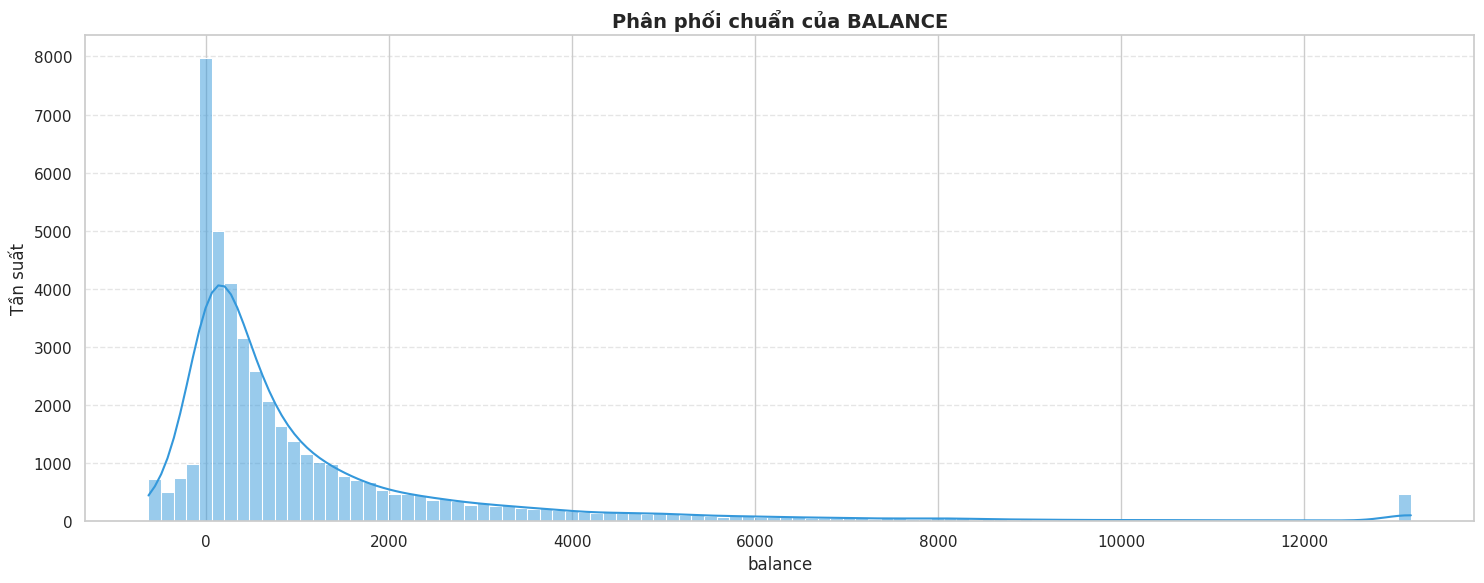

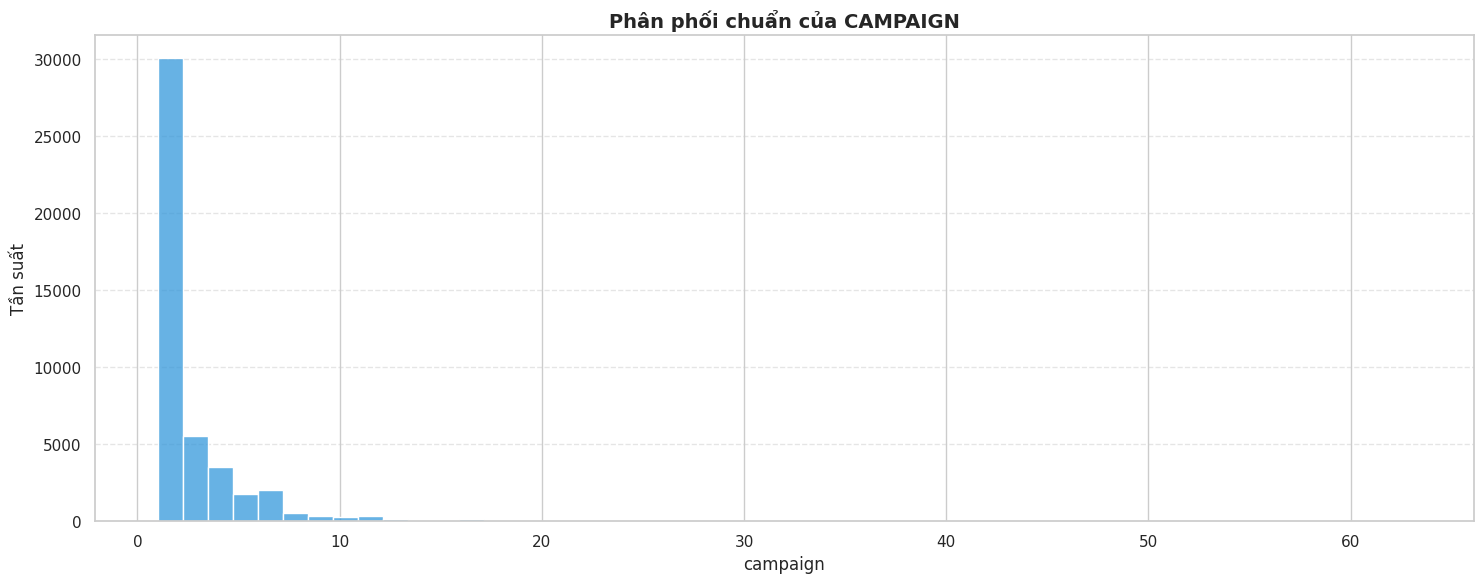

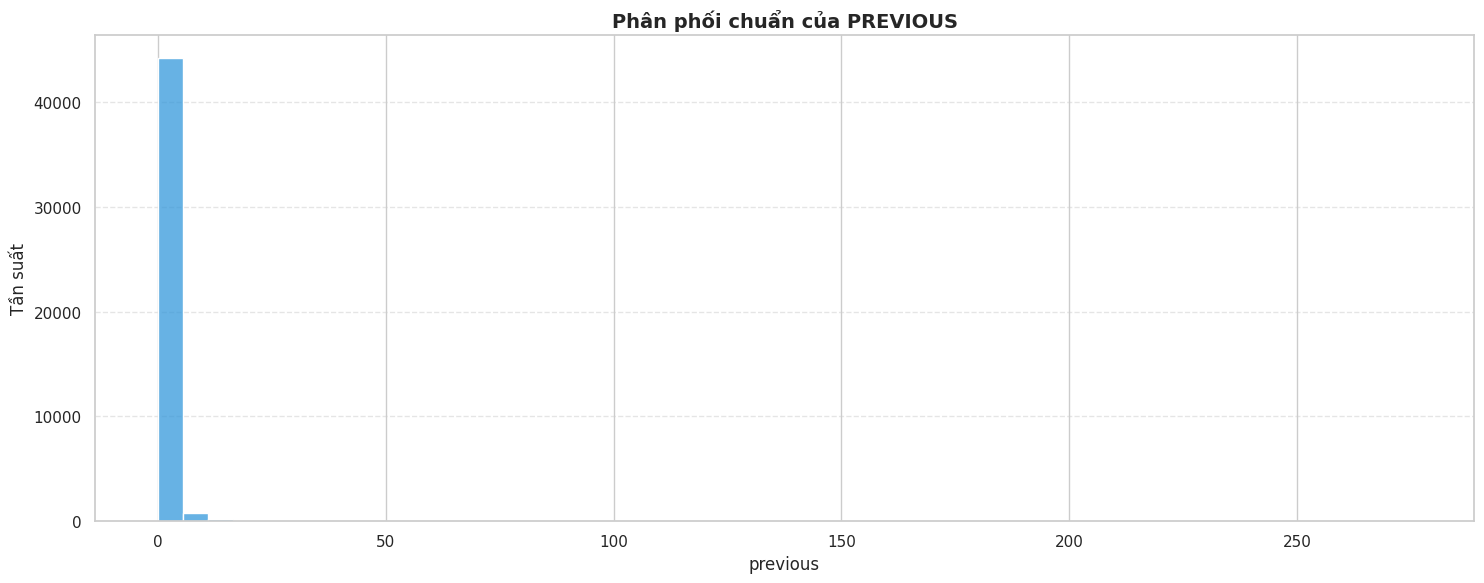

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Danh sách các biến cần quan sát kỹ
cols_to_viz = ['balance', 'campaign', 'previous']

for col in cols_to_viz:
    fig, ax = plt.subplots(figsize=(15, 6))

    # Vẽ Histogram với KDE sử dụng giá trị chuẩn (Standard Scale) và màu xanh nước biển
    if col == 'balance':
        # Tăng bins cho balance vì dải giá trị rộng
        sns.histplot(df_clean[col], kde=True, ax=ax, color='#3498db', bins=100)
        plt.title(f'Phân phối chuẩn của {col.upper()}', fontsize=14, fontweight='bold')
    else:
        sns.histplot(df_clean[col], kde=False, ax=ax, color='#3498db', bins=50)
        plt.title(f'Phân phối chuẩn của {col.upper()}', fontsize=14, fontweight='bold')

    plt.xlabel(col)
    plt.ylabel('Tần suất')
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

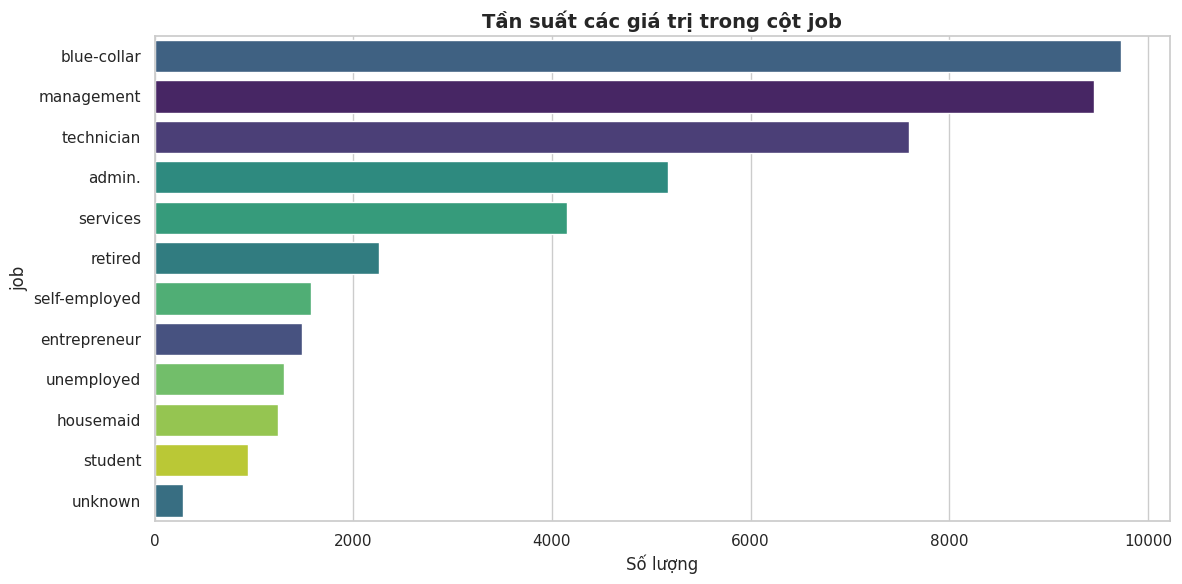

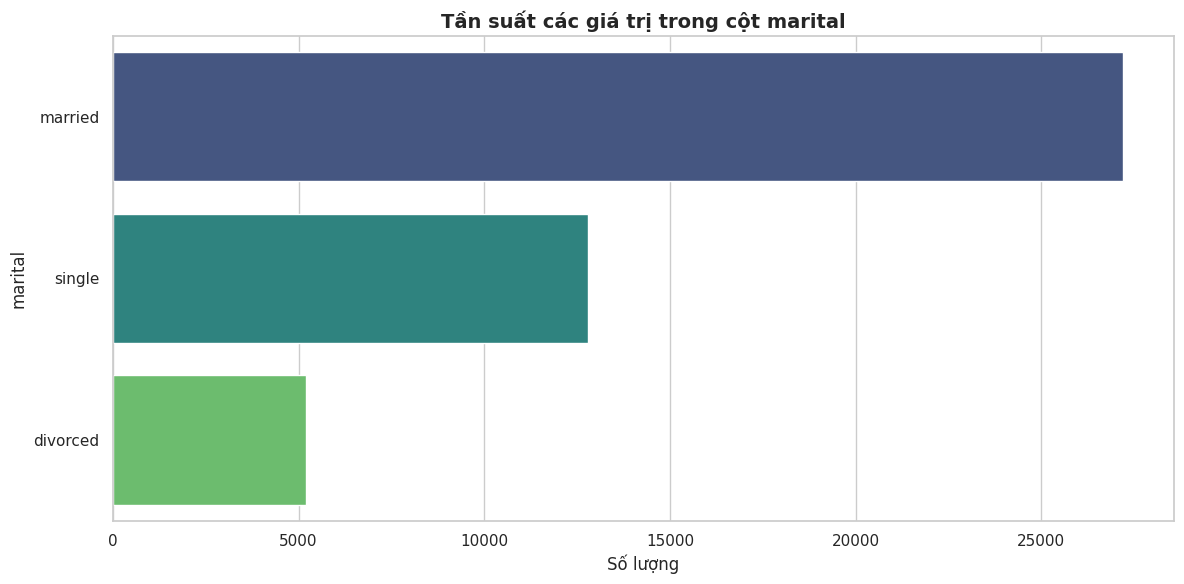

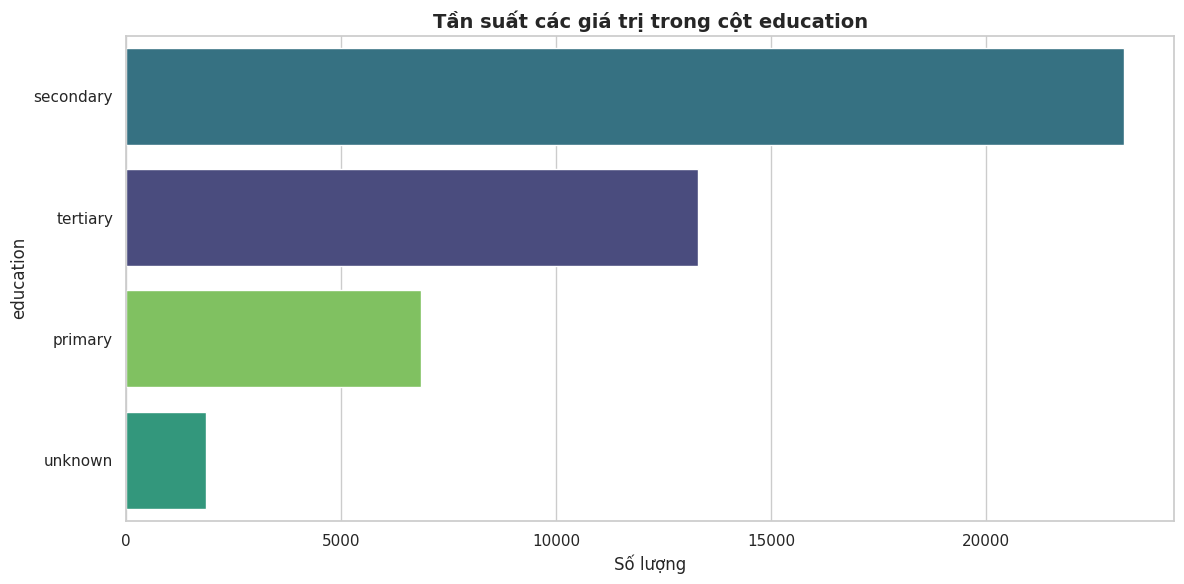

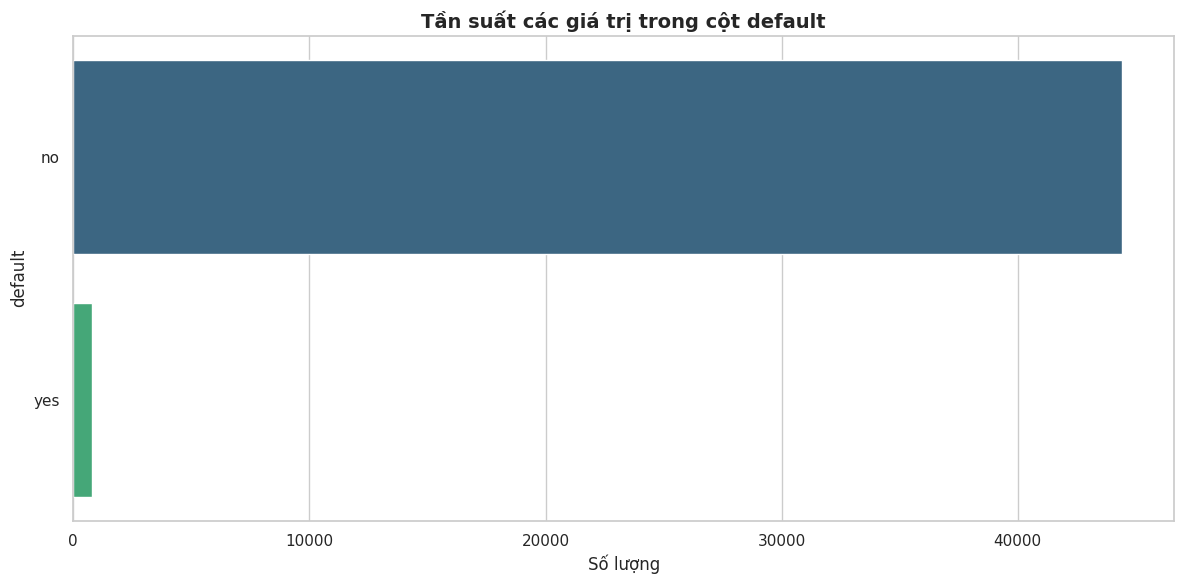

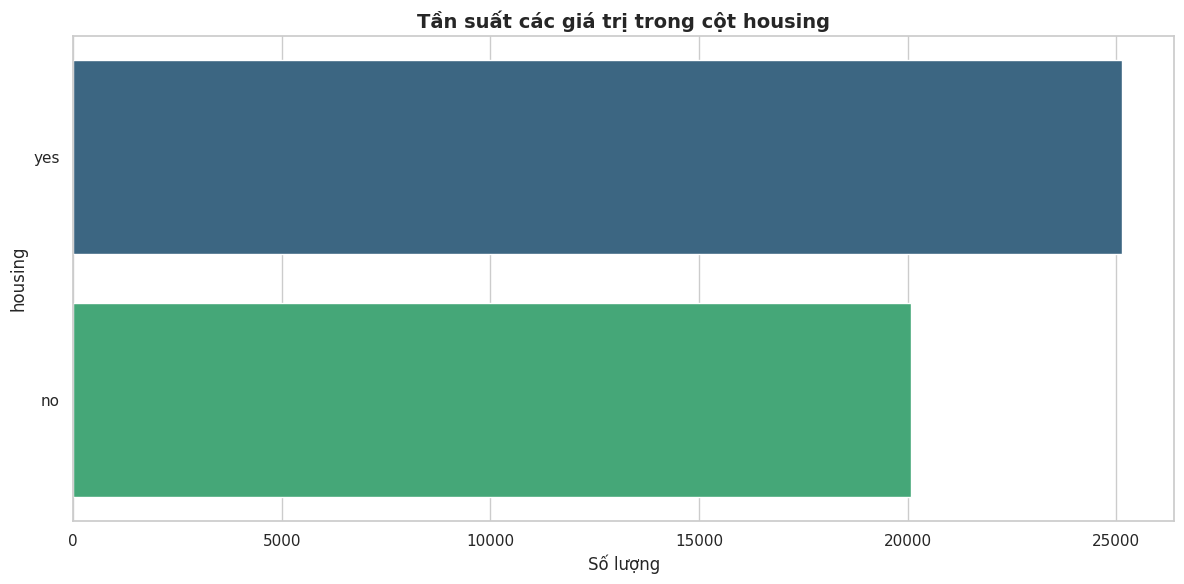

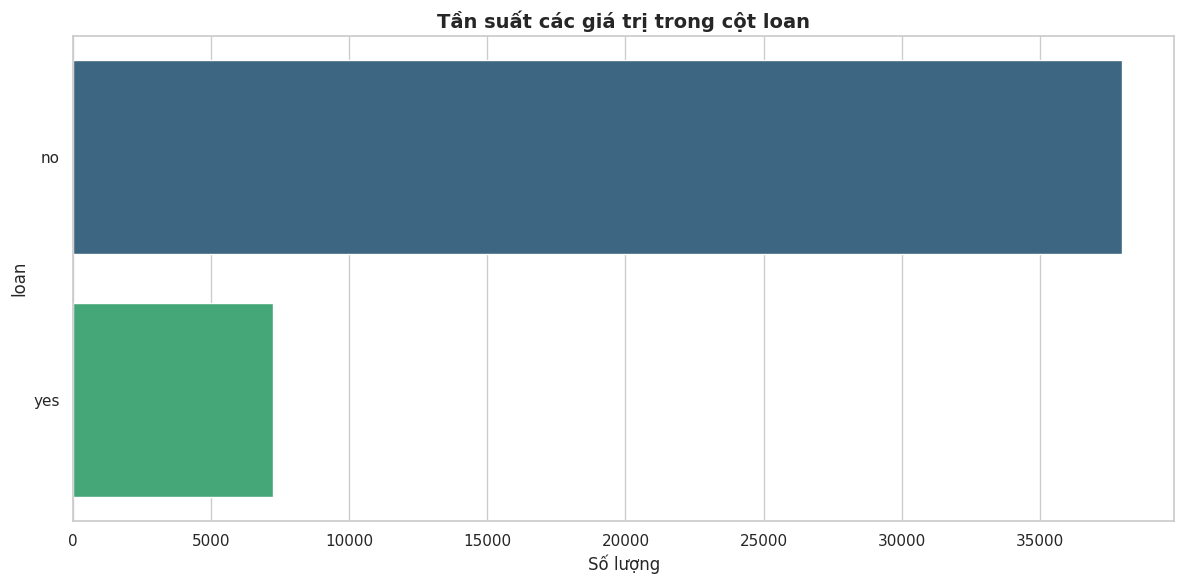

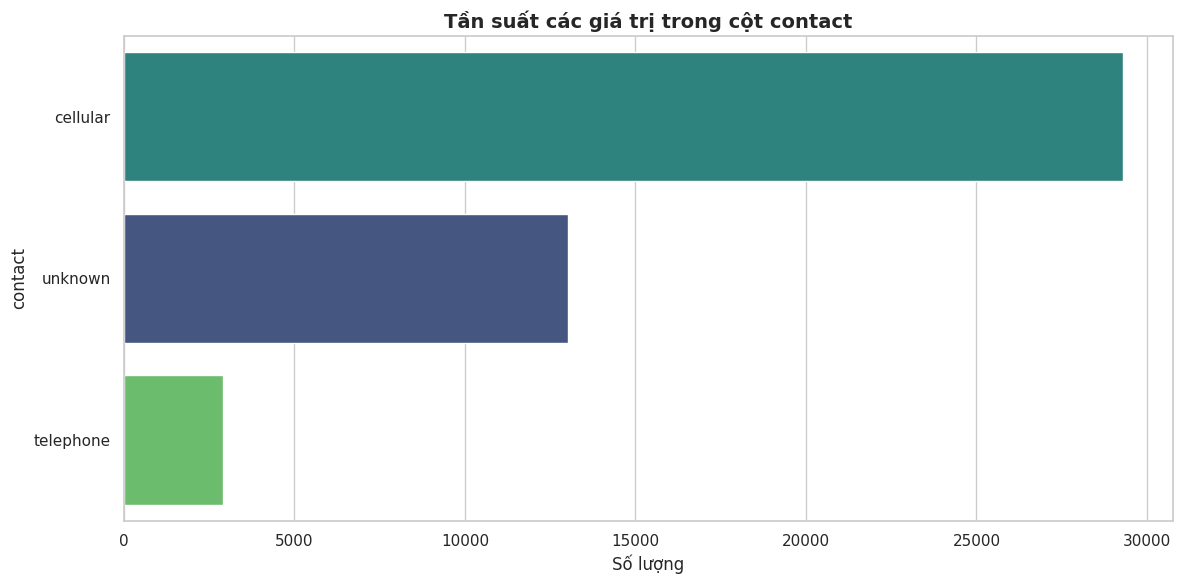

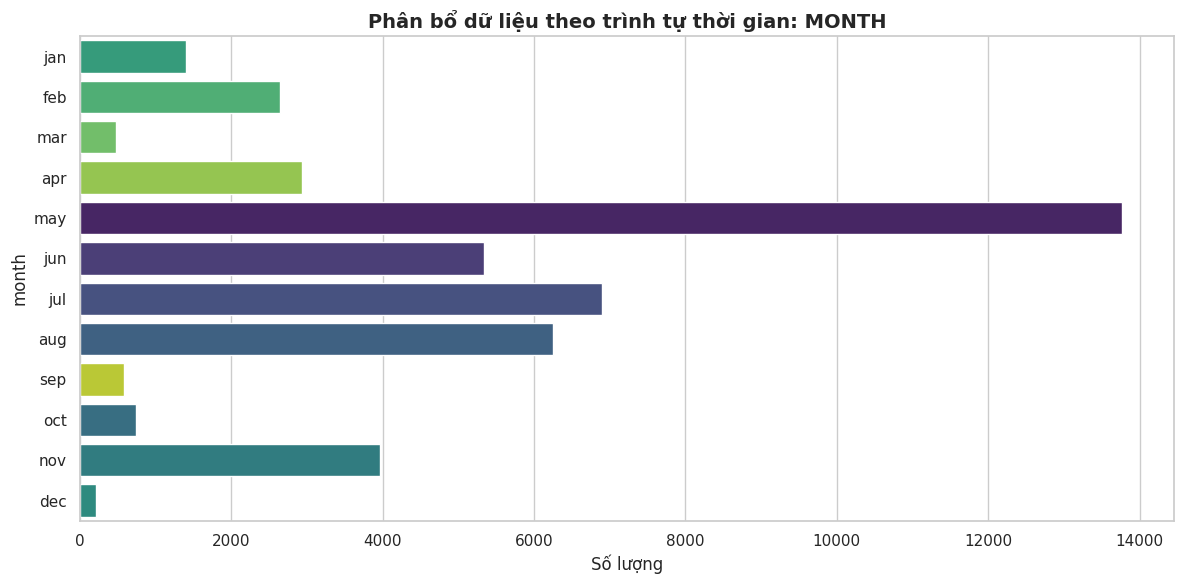

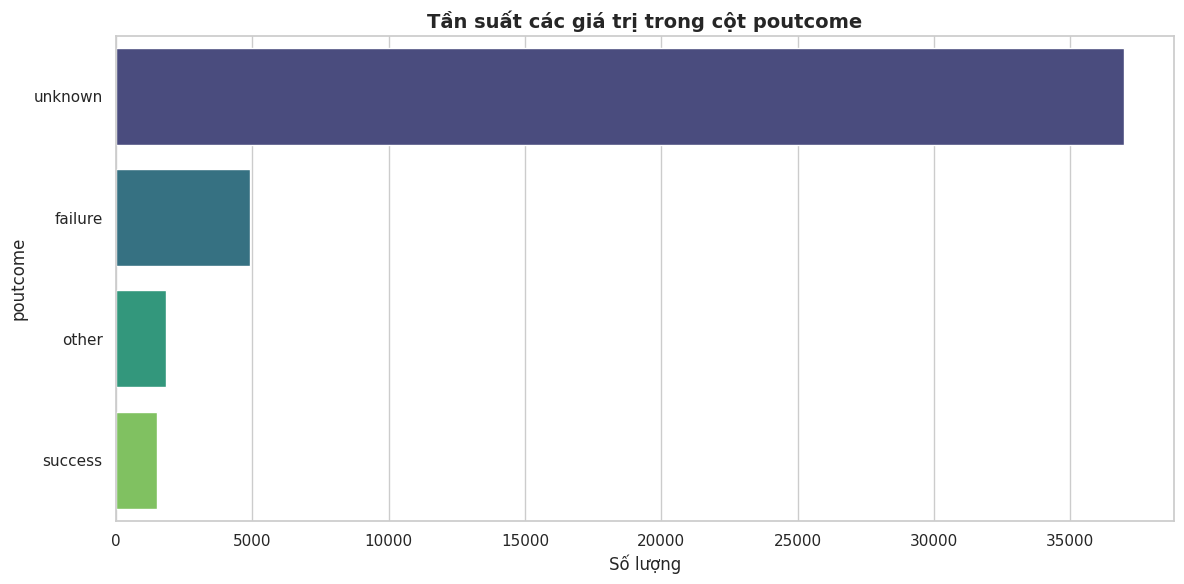

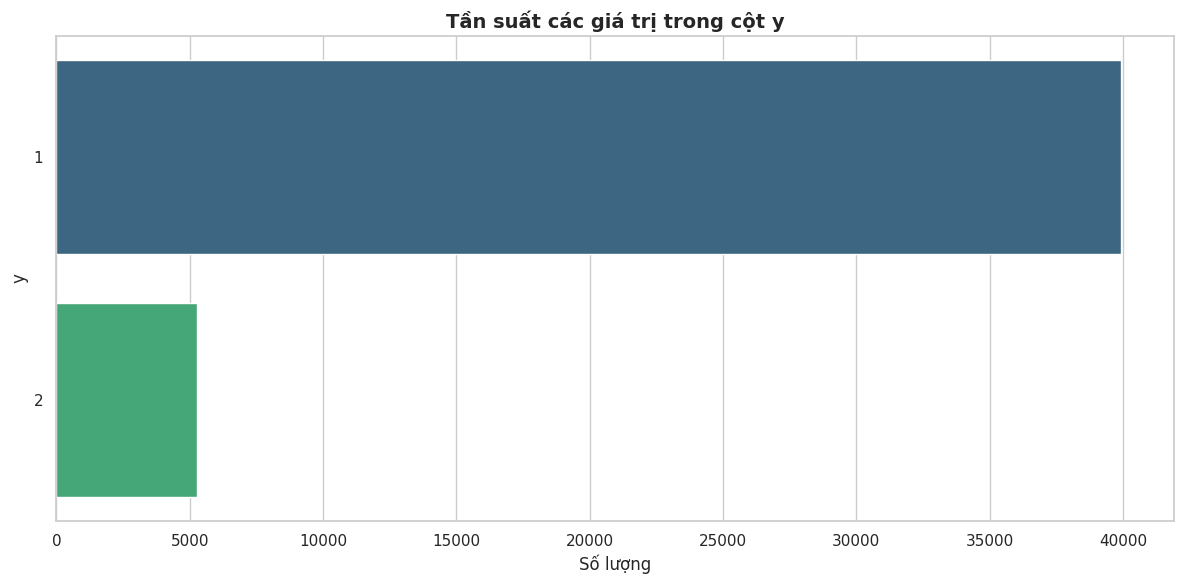

In [47]:
# 3.2 Trực quan hóa biến định tính (Categorical)
# Định nghĩa thứ tự các tháng để sắp xếp logic trên biểu đồ
month_order = ['jan', 'feb', 'mar', 'apr', 'may', 'jun', 'jul', 'aug', 'sep', 'oct', 'nov', 'dec']

for col in cat_cols:
    plt.figure(figsize=(12, 6))

    # Nếu là cột month, sử dụng thứ tự thời gian. Ngược lại sắp xếp theo tần suất.
    if col == 'month':
        # Lọc lấy các giá trị thực tế xuất hiện trong data dựa trên thứ tự chuẩn
        current_order = [m for m in month_order if m in df[col].unique()]
        sns.countplot(data=df, y=col, order=current_order, palette='viridis', hue=col, legend=False)
        plt.title(f'Phân bổ dữ liệu theo trình tự thời gian: {col.upper()}', fontsize=14, fontweight='bold')
    else:
        order = df[col].value_counts().index
        sns.countplot(data=df, y=col, order=order, palette='viridis', hue=col, legend=False)
        plt.title(f'Tần suất các giá trị trong cột {col}', fontsize=14, fontweight='bold')

    plt.xlabel('Số lượng')
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

In [9]:
# 3.3 Phân tích cụ thể các ngoại lệ (Outliers) bằng IQR
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return len(outliers), lower_bound, upper_bound

print("--- Thống kê Outliers theo phương pháp IQR ---")
for col in num_cols:
    count, lb, ub = detect_outliers_iqr(df, col)
    percentage = (count / len(df)) * 100
    print(f"{col}: {count} outliers ({percentage:.2f}%) | Ngưỡng: [{lb:.2f}, {ub:.2f}]")

--- Thống kê Outliers theo phương pháp IQR ---
age: 487 outliers (1.08%) | Ngưỡng: [10.50, 70.50]
balance: 4729 outliers (10.46%) | Ngưỡng: [-1962.00, 3462.00]
day: 0 outliers (0.00%) | Ngưỡng: [-11.50, 40.50]
duration: 3235 outliers (7.16%) | Ngưỡng: [-221.00, 643.00]
campaign: 3064 outliers (6.78%) | Ngưỡng: [-2.00, 6.00]
pdays: 8257 outliers (18.26%) | Ngưỡng: [-1.00, -1.00]
previous: 8257 outliers (18.26%) | Ngưỡng: [0.00, 0.00]


  Insight từ Univariate

1.  **Biến định lượng (Numerical):**
    *   **Age:** Tập trung chủ yếu ở độ tuổi lao động (30-50). Có một lượng nhỏ khách hàng trên 70 tuổi (outliers).
    *   **Balance:** Độ lệch rất lớn. Đa số có số dư thấp, nhưng tồn tại những khách hàng có số dư cực cao, ảnh hưởng đến giá trị trung bình.
    *   **Duration:** Hầu hết các cuộc gọi kết thúc nhanh chóng. Những cuộc gọi rất dài thường là ngoại lệ.
    *   **Campaign:** Thang đo Log cho thấy dù phần lớn chỉ bị liên hệ 1-3 lần, vẫn có những trường hợp cá biệt bị gọi tới hơn 50 lần, có thể gây phiền hà cho khách hàng.
    *   **Pdays & Previous:** Đa số giá trị là -1 và 0, xác nhận đây là tập khách hàng mới chưa từng được tiếp cận trong các chiến dịch trước đó.

2.  **Biến định tính (Categorical):**
    *   **Job & Education:** Các nhóm phổ biến nhất là lao động chân tay (blue-collar), quản lý (management) và trình độ trung học (secondary).
    *   **Target Variable (y):** Tỷ lệ khách hàng đồng ý (yes) chỉ chiếm khoảng 11.7%, cho thấy sự mất cân bằng dữ liệu (class imbalance) cần được xử lý khi huấn luyện mô hình.

##4.Phân tích target: phân phối lớp, class imbalance, baseline và numerical features theo target

/tmp/ipykernel_1228/4288991688.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='y', data=df, palette=['#1f77b4', '#ff7f0e'])


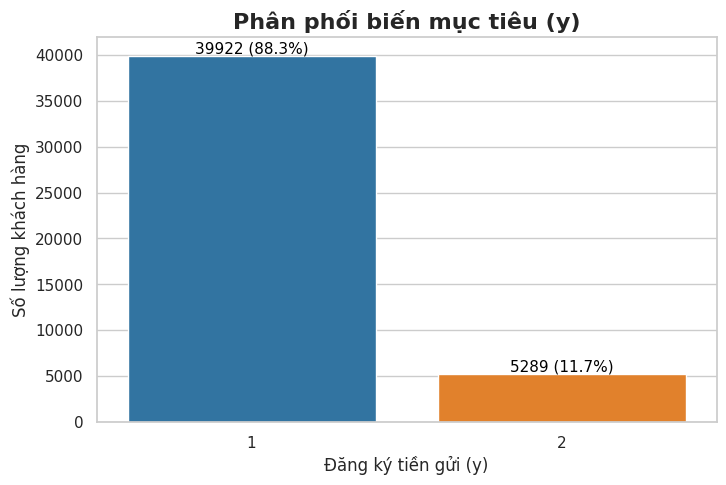

Tỷ lệ Baseline (Majority Class): 88.30%


In [10]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 4.1 Phân tích phân phối biến mục tiêu (Target Distribution)
target_counts = df['y'].value_counts()
target_pct = df['y'].value_counts(normalize=True) * 100

plt.figure(figsize=(8, 5))
ax = sns.countplot(x='y', data=df, palette=['#1f77b4', '#ff7f0e'])
plt.title('Phân phối biến mục tiêu (y)', fontsize=16, fontweight='bold')
plt.xlabel('Đăng ký tiền gửi (y)', fontsize=12)
plt.ylabel('Số lượng khách hàng', fontsize=12)

# Thêm nhãn % trên cột
for i, p in enumerate(ax.patches):
    ax.annotate(f'{target_counts.iloc[i]} ({target_pct.iloc[i]:.1f}%)',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=11, color='black', xytext=(0, 5),
                textcoords='offset points')

plt.show()

print(f"Tỷ lệ Baseline (Majority Class): {target_pct.max():.2f}%")

Class Imbalance — mất cân bằng lớp

/tmp/ipykernel_1228/3210483622.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='y', y=col, data=df, ax=axes[i], palette=['#1f77b4', '#ff7f0e'])
/tmp/ipykernel_1228/3210483622.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='y', y=col, data=df, ax=axes[i], palette=['#1f77b4', '#ff7f0e'])
/tmp/ipykernel_1228/3210483622.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='y', y=col, data=df, ax=axes[i], palette=['#1f77b4', '#ff7f0e'])
/tmp/ipykernel_1228/3210483622.py:8: FutureWarning: 

Passing `palette` without assigning `hue` i

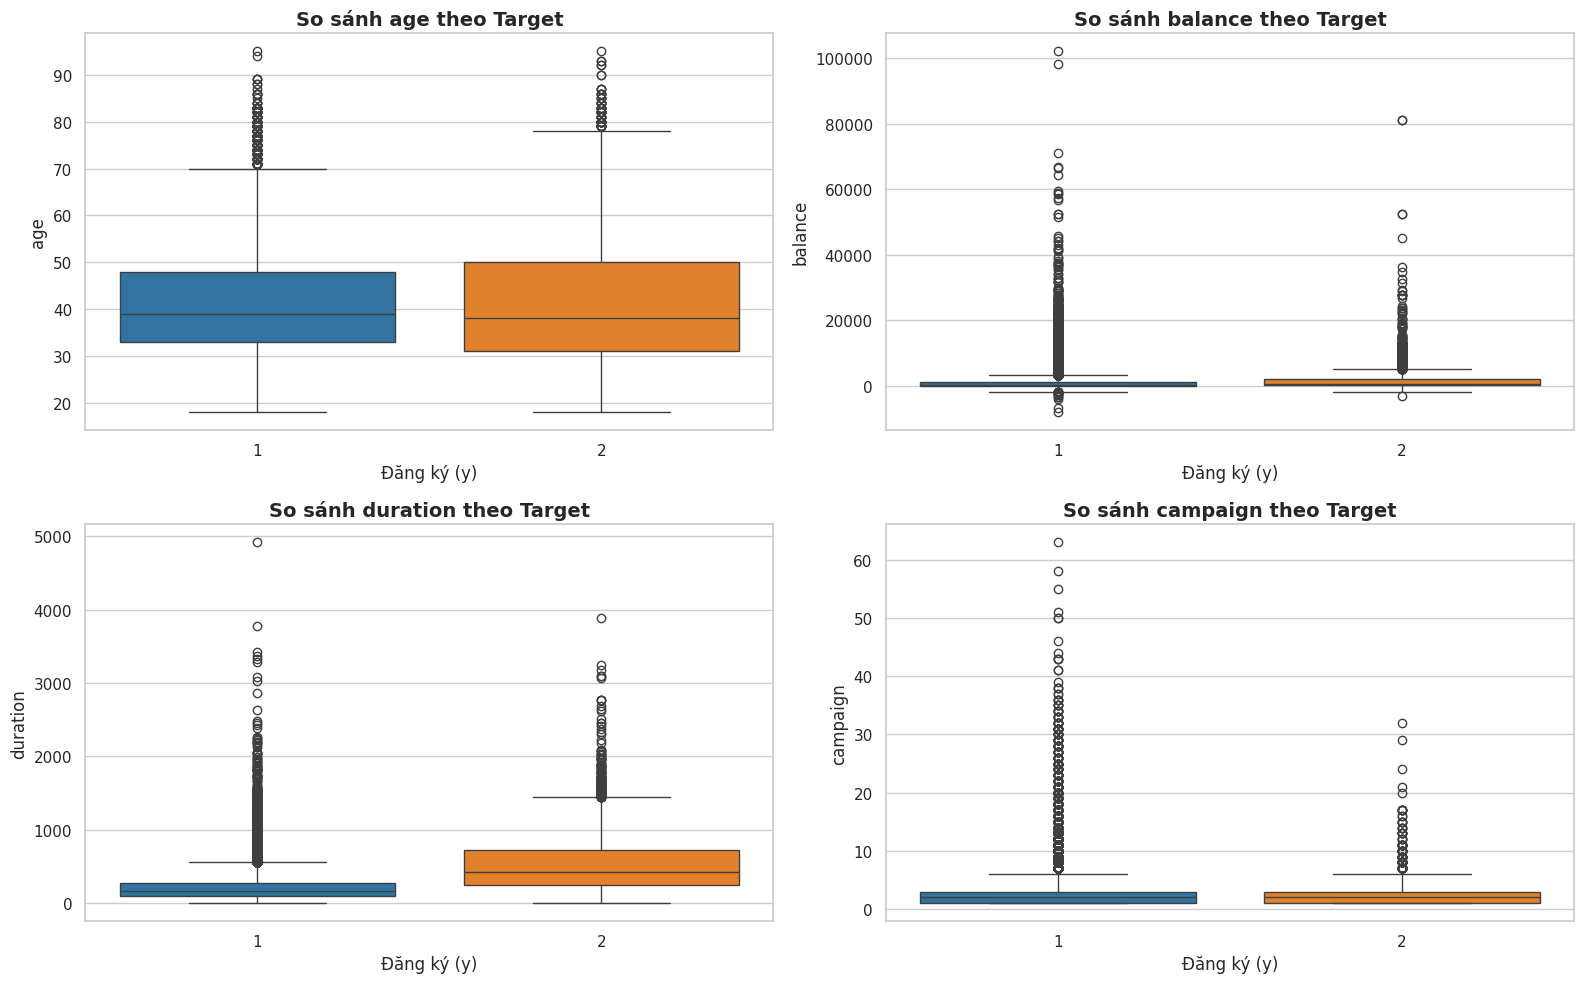

In [11]:
# 4.2 Phân tích các biến định lượng theo Target
num_cols_to_plot = ['age', 'balance', 'duration', 'campaign']

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols_to_plot):
    sns.boxplot(x='y', y=col, data=df, ax=axes[i], palette=['#1f77b4', '#ff7f0e'])
    axes[i].set_title(f'So sánh {col} theo Target', fontsize=14, fontweight='bold')
    axes[i].set_xlabel('Đăng ký (y)', fontsize=12)
    axes[i].set_ylabel(col, fontsize=12)

plt.tight_layout()
plt.show()

Nhận xét từ phân tích Target:

1.  **Class Imbalance:** Dữ liệu bị mất cân bằng nghiêm trọng. Nhóm không đăng ký (no) chiếm **~88.3%**, trong khi nhóm đăng ký (yes) chỉ chiếm **~11.7%**.
2.  **Thời lượng cuộc gọi (Duration):** Biểu đồ boxplot cho thấy những khách hàng đồng ý (yes) thường có thời lượng cuộc gọi dài hơn rõ rệt so với nhóm 'no'. Đây là một đặc trưng mạnh nhưng cần lưu ý vì nó là biến phát sinh sau khi thực hiện cuộc gọi.
3.  **Số dư (Balance):** Không có sự khác biệt quá lớn về trung vị, nhưng nhóm 'yes' dường như có phân phối số dư ổn định hơn ở một số phân khúc nhất định.
4.  **Chiến dịch (Campaign):** Nhóm đồng ý (yes) thường có số lần liên hệ ít hơn trong chiến dịch hiện tại so với nhóm bị liên hệ quá nhiều lần mà vẫn từ chối.

 ## 5.Categorical → target: crosstab, conversion rate, job, marital, education, contact, poutcome

/tmp/ipykernel_1228/1070162335.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=yes_rates.index, y=yes_rates.values, palette='viridis', alpha=0.7)


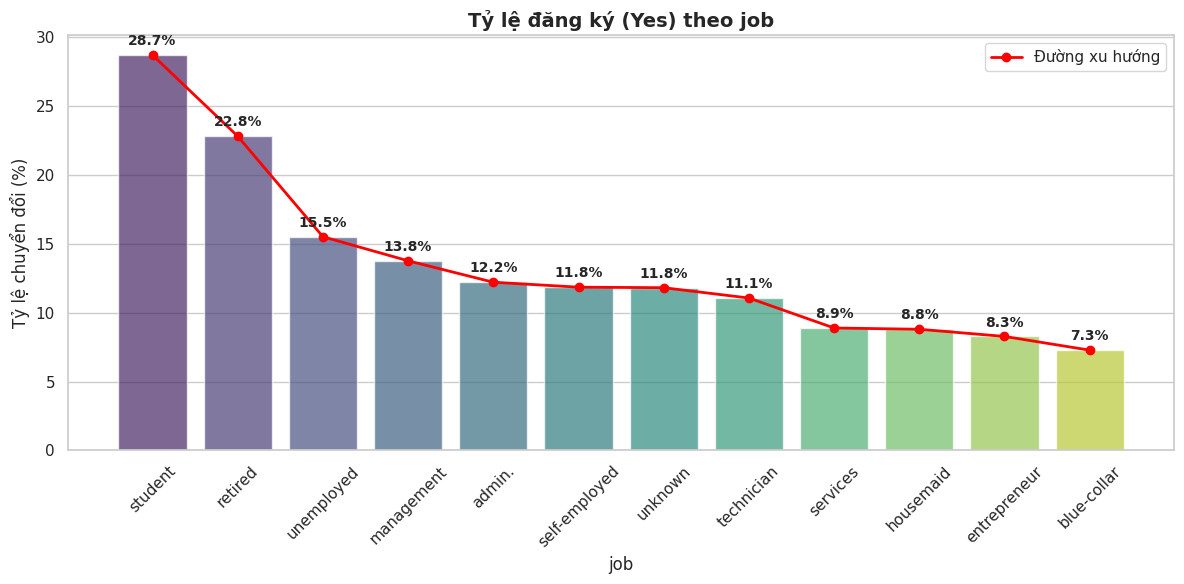

/tmp/ipykernel_1228/1070162335.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=yes_rates.index, y=yes_rates.values, palette='viridis', alpha=0.7)


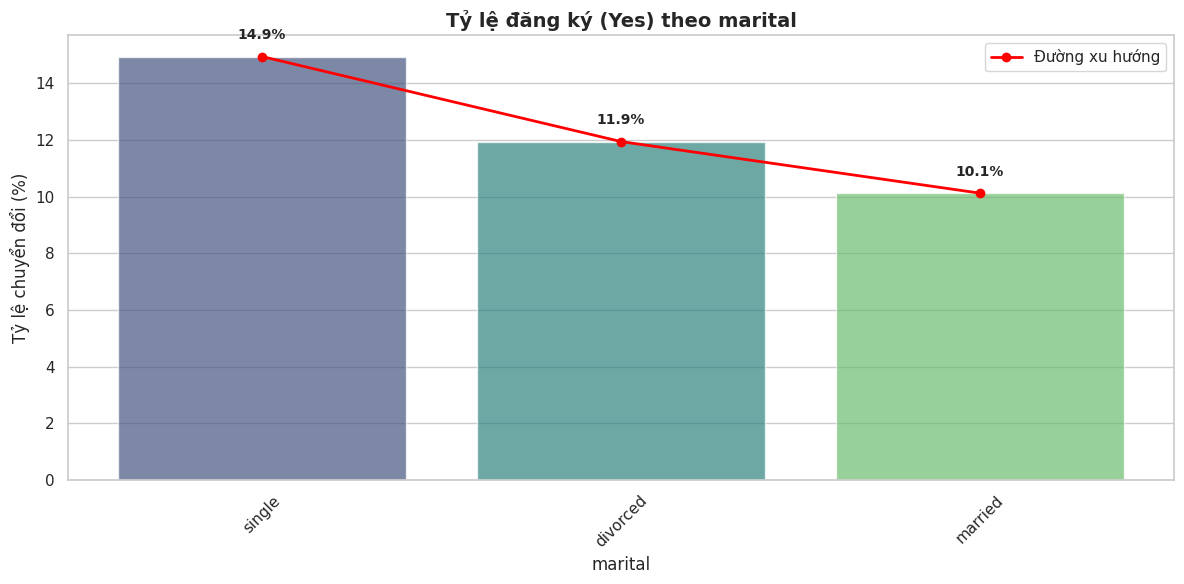

/tmp/ipykernel_1228/1070162335.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=yes_rates.index, y=yes_rates.values, palette='viridis', alpha=0.7)


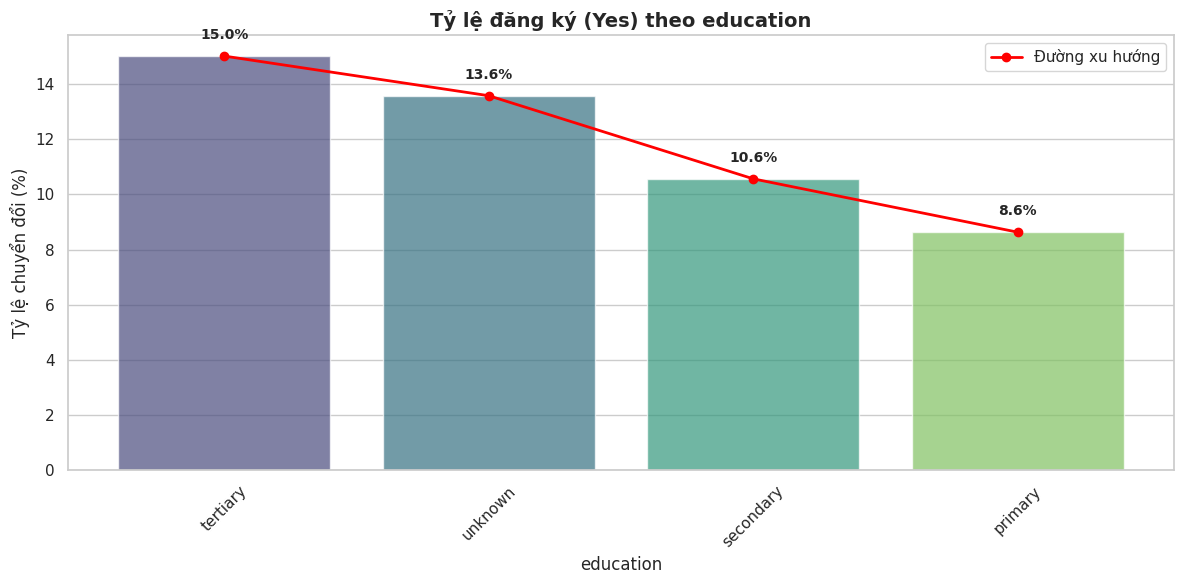

/tmp/ipykernel_1228/1070162335.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=yes_rates.index, y=yes_rates.values, palette='viridis', alpha=0.7)


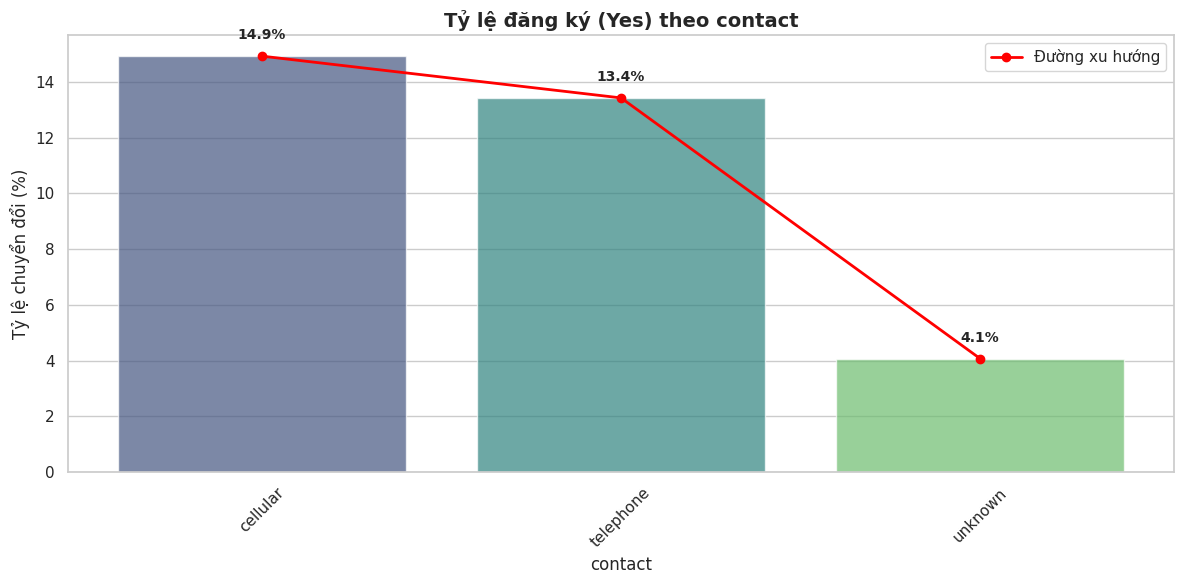

/tmp/ipykernel_1228/1070162335.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=yes_rates.index, y=yes_rates.values, palette='viridis', alpha=0.7)


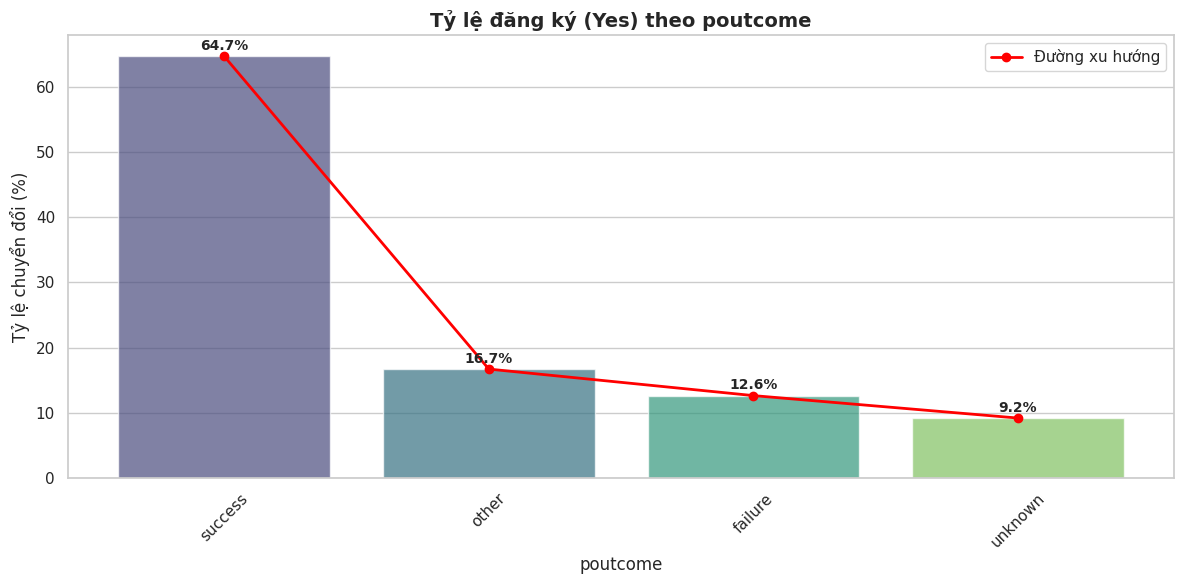

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# 4.3 Phân tích tỷ lệ chuyển đổi (Yes) và đường xu hướng
cat_cols_to_plot = ['job', 'marital', 'education', 'contact', 'poutcome']

for col in cat_cols_to_plot:
    # 1. Tính toán tỷ lệ phần trăm chuyển đổi (Conversion Rate)
    # props[1] tương ứng với nhãn 'yes'
    props = df.groupby(col)['y'].value_counts(normalize=True).unstack() * 100
    props = props.sort_values(by=props.columns[1], ascending=False)

    # Lấy dữ liệu tỷ lệ Yes
    yes_rates = props[props.columns[1]]

    plt.figure(figsize=(12, 6))

    # 2. Vẽ biểu đồ cột cho giá trị Yes
    ax = sns.barplot(x=yes_rates.index, y=yes_rates.values, palette='viridis', alpha=0.7)

    # 3. Vẽ đường xu hướng (Trend line)
    plt.plot(range(len(yes_rates)), yes_rates.values, marker='o', color='red', linewidth=2, label='Đường xu hướng')

    plt.title(f'Tỷ lệ đăng ký (Yes) theo {col}', fontsize=14, fontweight='bold')
    plt.xlabel(col, fontsize=12)
    plt.ylabel('Tỷ lệ chuyển đổi (%)', fontsize=12)
    plt.xticks(rotation=45)
    plt.legend(loc='upper right')

    # 4. Thêm nhãn % lên trên mỗi cột
    for i, p in enumerate(ax.patches):
        ax.text(p.get_x() + p.get_width()/2., p.get_height() + 0.5,
                f'{p.get_height():.1f}%',
                ha='center', va='bottom', fontsize=10, fontweight='bold')

    plt.tight_layout()
    plt.show()

**Phân tích chi tiết và Insight :**

1.  **Chiến lược dựa trên `poutcome` (Kết quả trước đó):**
    *   **Insight:** Khách hàng từng thành công (`success`) có tỷ lệ chuyển đổi lên tới **>60%**, cao gấp 5 lần mức trung bình.
    *   **Hành động:** Đây là nhóm khách hàng "vàng". Cần ưu tiên tối đa nguồn lực chăm sóc lại nhóm này.

2.  **Đặc điểm nghề nghiệp (`job`):**
    *   **Insight:** `student` (sinh viên) và `retired` (người già) có tỷ lệ đồng ý cao nhất. Nhóm `blue-collar` (lao động tay chân) chiếm số lượng đông nhất nhưng tỷ lệ đồng ý lại thấp nhất.
    *   **Hành động:** Thiết kế các gói tiền gửi tiết kiệm dành riêng cho sinh viên (tích lũy) và người nghỉ hưu (an dưỡng) để tối ưu hóa conversion rate.

3.  **Tình trạng hôn nhân (`marital`) & Học vấn (`education`):**
    *   **Insight:** Người độc thân (`single`) và người có học vấn cao (`tertiary`) có xu hướng cởi mở hơn với các sản phẩm tài chính.
    *   **Hành động:** Tập trung các chiến dịch quảng cáo qua kênh kỹ thuật số hướng đến đối tượng trẻ, độc thân, có trình độ.

4.  **Kênh liên lạc (`contact`):**
    *   **Insight:** Liên lạc qua di động (`cellular`) vượt trội hơn hẳn so với điện thoại bàn. Đặc biệt, nhóm `unknown` có tỷ lệ rất thấp.
    *   **Hành động:** Làm sạch dữ liệu, cập nhật số điện thoại di động của khách hàng để thay thế các số điện thoại bàn hoặc thông tin bị thiếu.

## 6.Correlation
- numerical vs numerical  
- cat vs cat
- num vs cat  
- Chi-square  và tổng hợp insight EDA

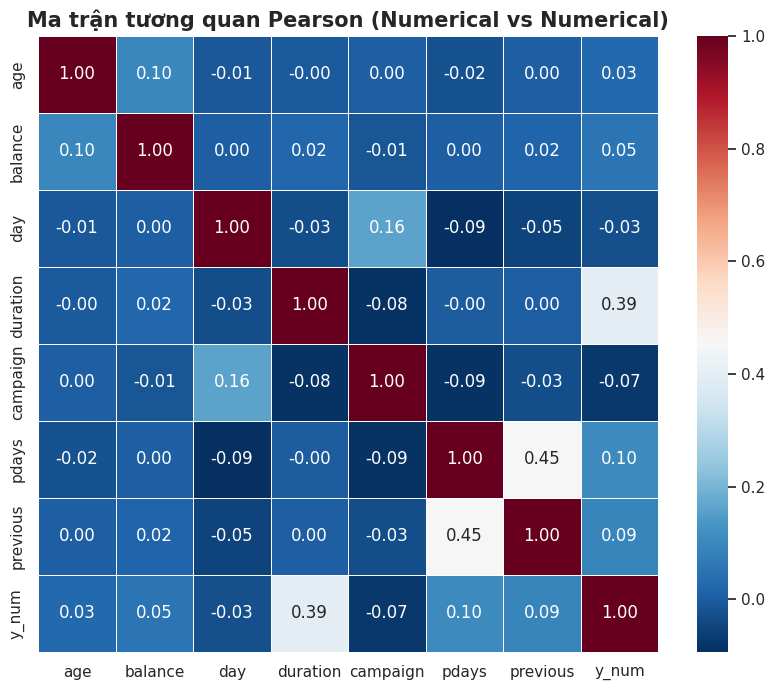

In [13]:
#numerical vs numerical
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Định nghĩa lại các cột số để tránh lỗi NameError
num_cols = df.select_dtypes(include=['float64', 'int64']).columns

# --- 6.1 Tương quan Định lượng vs Định lượng (Pearson) ---
plt.figure(figsize=(10, 8))

# Chuẩn bị dữ liệu: Copy df và map y sang dạng số (1->0, 2->1) để tính tương quan
df_corr = df.copy()
df_corr['y_num'] = df_corr['y'].map({'1': 0, '2': 1})

corr_matrix = df_corr[list(num_cols) + ['y_num']].corr()

sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', fmt='.2f', linewidths=0.5)
plt.title('Ma trận tương quan Pearson (Numerical vs Numerical)', fontsize=15, fontweight='bold')
plt.show()

 Phân tích tương quan Định tính vs Định tính (Categorical vs Categorical)
 kiểm định Chi-square và hệ số Cramer's V để đo lường mức độ liên kết giữa các đặc trưng định tính và biến mục tiêu.

/tmp/ipykernel_1228/2260301651.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Cramer's V", y='Biến', data=cramers_df, palette='magma')


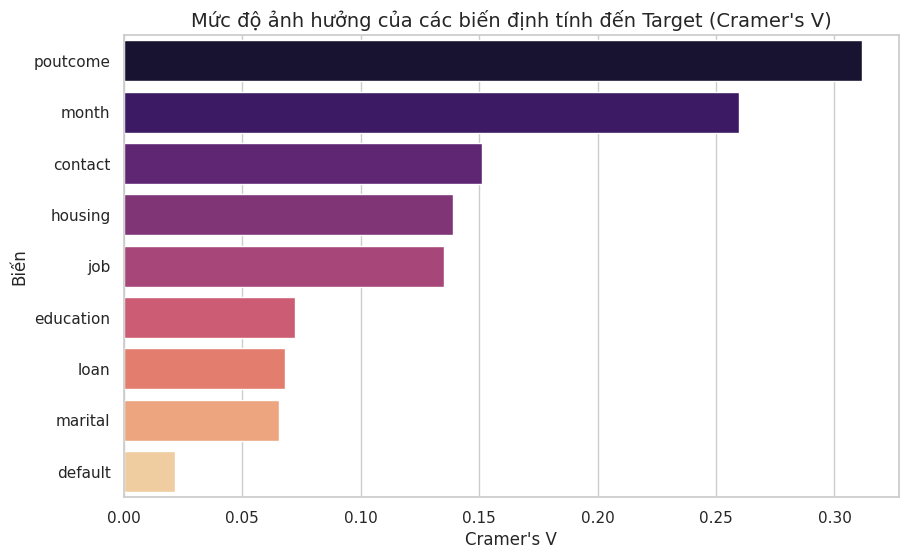

,Biến,Cramer's V
8,poutcome,0.311560
7,month,0.259772
6,contact,0.151211
4,housing,0.139025
0,job,0.135094
2,education,0.072238
5,loan,0.067929
1,marital,0.065590
3,default,0.021656


In [14]:
#Categorical vs Categorical
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency

def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

cat_cols_analysis = ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']

results = []
for col in cat_cols_analysis:
    v = cramers_v(df[col], df['y'])
    results.append({'Biến': col, "Cramer's V": v})

cramers_df = pd.DataFrame(results).sort_values(by="Cramer's V", ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x="Cramer's V", y='Biến', data=cramers_df, palette='magma')
plt.title("Mức độ ảnh hưởng của các biến định tính đến Target (Cramer's V)", fontsize=14)
plt.show()

display(cramers_df)

--- THỐNG KÊ MÔ TẢ BIẾN SỐ THEO NHÓM TARGET ---


,age,balance,day,duration,campaign,pdays,previous
y,,,,,,,
1,40.838986,1303.714969,15.892290,221.182806,2.846350,36.421372,0.502154
2,41.670070,1804.267915,15.158253,537.294574,2.141047,68.702968,1.170354


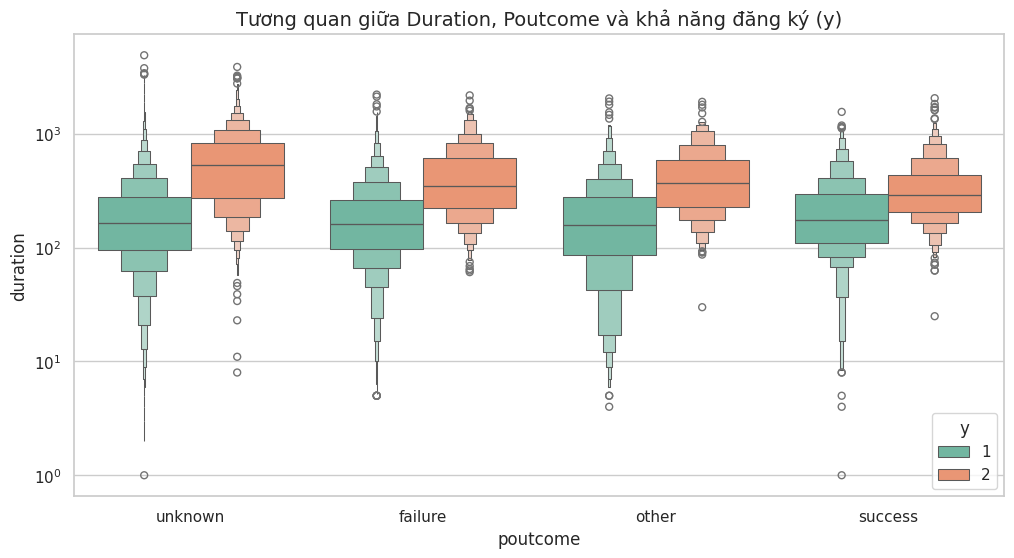

In [16]:
# Định nghĩa lại num_cols
num_cols = df.select_dtypes(include=['float64', 'int64']).columns

# --- 6.3 Tương quan Định lượng vs Định tính (Numerical vs Categorical) ---
print("--- THỐNG KÊ MÔ TẢ BIẾN SỐ THEO NHÓM TARGET ---")
display(df.groupby('y')[num_cols].mean())

# Trực quan hóa tương quan mạnh nhất: Duration vs Poutcome
plt.figure(figsize=(12, 6))
sns.boxenplot(x='poutcome', y='duration', hue='y', data=df, palette='Set2')
plt.title('Tương quan giữa Duration, Poutcome và khả năng đăng ký (y)', fontsize=14)
plt.yscale('log') # Dùng thang log vì duration có outlier lớn
plt.show()

 Phân tích tương quan giữa các cặp biến độc lập (Feature vs Feature)
Việc này giúp hiểu rõ hơn về chân dung khách hàng và loại bỏ các biến bị trùng lặp thông tin.

/tmp/ipykernel_1228/2131746389.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='education', y='balance', data=df, palette='viridis', errorbar=None)


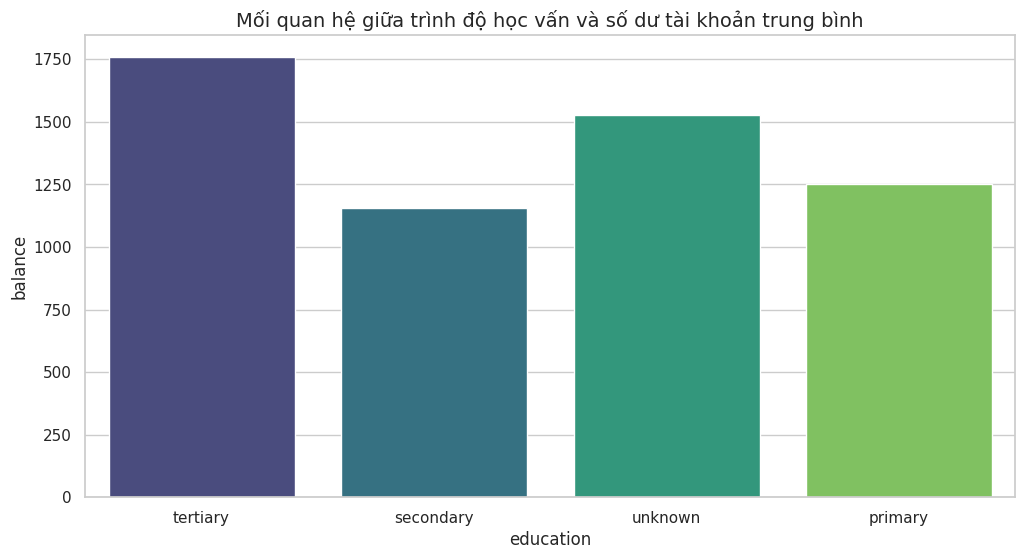

/tmp/ipykernel_1228/2131746389.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='job', y='age', data=df, palette='magma')


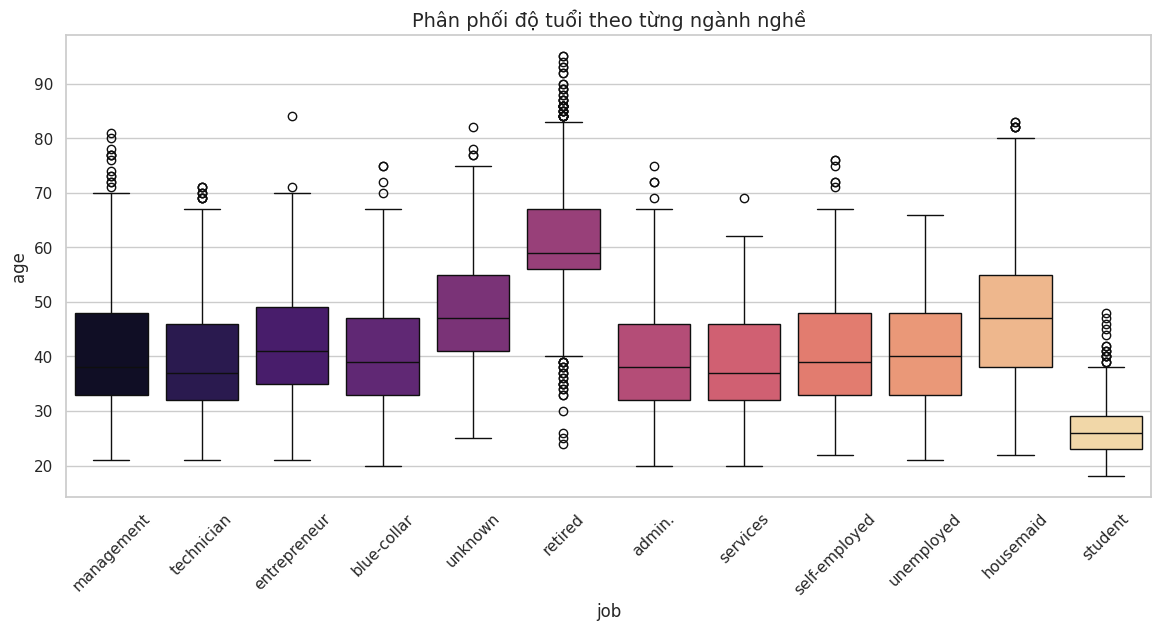

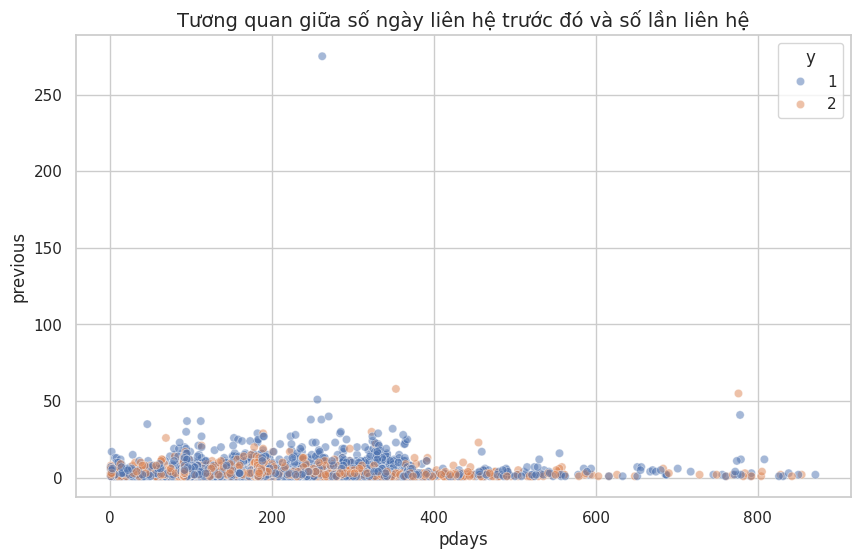

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Mối quan hệ giữa Học vấn và Số dư tài khoản (Education vs Balance)
# Thêm errorbar=None để xóa các vạch đen (khoảng tin cậy)
plt.figure(figsize=(12, 6))
sns.barplot(x='education', y='balance', data=df, palette='viridis', errorbar=None)
plt.title('Mối quan hệ giữa trình độ học vấn và số dư tài khoản trung bình', fontsize=14)
plt.show()

# 2. Mối quan hệ giữa Nghề nghiệp và Tuổi (Job vs Age)
plt.figure(figsize=(14, 6))
sns.boxplot(x='job', y='age', data=df, palette='magma')
plt.xticks(rotation=45)
plt.title('Phân phối độ tuổi theo từng ngành nghề', fontsize=14)
plt.show()

# 3. Mối quan hệ giữa pdays và previous (Tương quan định lượng mạnh nhất)
plt.figure(figsize=(10, 6))
sns.scatterplot(x='pdays', y='previous', hue='y', data=df[df['pdays'] != -1], alpha=0.5)
plt.title('Tương quan giữa số ngày liên hệ trước đó và số lần liên hệ', fontsize=14)
plt.show()

In [18]:
from scipy.stats import chi2_contingency

# Định nghĩa lại các cột định tính
cat_cols = df.select_dtypes(include=['object']).columns

print("--- KIỂM ĐỊNH CHI-SQUARE (Categorical vs Target y) ---\n")
chi2_results = []

for col in cat_cols:
    if col == 'y': continue

    # Tạo bảng tần suất
    contingency_table = pd.crosstab(df[col], df['y'])

    # Kiểm định Chi-square
    chi2, p, dof, ex = chi2_contingency(contingency_table)

    chi2_results.append({
        'Biến': col,
        'Chi2 Statistic': chi2,
        'P-value': p,
        'Ý nghĩa (P < 0.05)': 'Có' if p < 0.05 else 'Không'
    })

chi2_df = pd.DataFrame(chi2_results).sort_values(by='Chi2 Statistic', ascending=False)
display(chi2_df)

print("\nGiải thích: Chi2 Statistic càng cao và P-value càng nhỏ (<0.05) chứng tỏ biến đó có ảnh hưởng mạnh đến biến mục tiêu.")

--- KIỂM ĐỊNH CHI-SQUARE (Categorical vs Target y) ---



,Biến,Chi2 Statistic,P-value,Ý nghĩa (P < 0.05)
8,poutcome,4391.506589,0.000000e+00,Có
7,month,3061.838938,0.000000e+00,Có
6,contact,1035.714225,1.251738e-225,Có
4,housing,874.822449,2.918798e-192,Có
0,job,836.105488,3.337122e-172,Có
2,education,238.923506,1.626656e-51,Có
5,loan,209.616980,1.665061e-47,Có
1,marital,196.495946,2.145100e-43,Có
3,default,22.202250,2.453861e-06,Có



Giải thích: Chi2 Statistic càng cao và P-value càng nhỏ (<0.05) chứng tỏ biến đó có ảnh hưởng mạnh đến biến mục tiêu.


 TỔNG HỢP  INSIGHT TỪ EDA

Sau khi phân tích chi tiết, chúng ta có các kết luận quan trọng để xây dựng mô hình:

1.  **Biến quan trọng nhất (Top Drivers):**
    *   **Duration:** Thời lượng cuộc gọi là yếu tố dự báo mạnh nhất. Cuộc gọi càng lâu, xác suất đồng ý càng cao.
    *   **Poutcome (Success):** Những người đã đồng ý ở chiến dịch trước có tỷ lệ quay lại cực cao (>64%).
    *   **Contact:** Kênh `cellular` (di động) mang lại hiệu quả vượt trội so với các kênh khác.

2.  **Mối quan hệ giữa các biến (Correlations):**
    *   `pdays` và `previous` có tương quan thuận mạnh (~0.45). Điều này dễ hiểu vì chúng cùng phản ánh lịch sử liên hệ.
    *   Không có hiện tượng đa cộng tuyến (multicollinearity) nghiêm trọng giữa các biến độc lập, giúp mô hình ổn định.

3.  **Thách thức về Dữ liệu:**
    *   **Class Imbalance:** Tỷ lệ 88% - 12% là một trở ngại lớn. Cần cân nhắc các kỹ thuật như **SMOTE** hoặc điều chỉnh **class_weight** khi training.
    *   **Missing/Unknown Values:** Cột `poutcome` và `contact` có lượng `unknown` rất lớn. Cần xử lý khéo léo để không làm mất thông tin.
    *   **Outliers:** `balance` và `duration` có các giá trị cực biên rất lớn, có thể cần xử lý bằng Robust Scaling hoặc Capping.

#III.Data Preparation

##7.Data cleaning: missing/unknown, duplicate, invalid values và quyết định xử lý outlier

biến pday có nhiều giá trị có nghĩa -1 là chưa từng liên hệ trước đó

In [54]:
import numpy as np

# 1. Chuyển 'unknown' thành NaN để kiểm tra tổng quan (tùy chọn)
import numpy as np

# 1.1 Chuyển 'unknown' thành NaN cho toàn bộ DataFrame
df_clean = df_clean.replace('unknown', np.nan)

# 1.2. Kiểm tra lại số lượng giá trị thiếu sau khi chuyển đổi
print("--- Thống kê giá trị thiếu (NaN) sau khi chuyển đổi 'unknown' ---")
missing_stats = df_clean.isnull().sum()
display(missing_stats[missing_stats > 0])

# 1.3. Tính tỷ lệ phần trăm thiếu
print("\nTỷ lệ phần trăm thiếu trên tổng dữ liệu:")
missing_pct = (df_clean.isnull().sum() / len(df_clean)) * 100
display(missing_pct[missing_pct > 0])
# 2. Loại bỏ các cột không cần thiết hoặc gây đa cộng tuyến
# loại bỏ pdays có quá nhiều giá trị -1
df_clean = df.drop(columns=['pdays'])

# 3. Xử lý Outliers bằng phương pháp Capping (giới hạn ở percentile 1% và 99%)
def cap_outliers(series, lower_quantile=0.01, upper_quantile=0.99):
    lower_limit = series.quantile(lower_quantile)
    upper_limit = series.quantile(upper_quantile)
    return series.clip(lower=lower_limit, upper=upper_limit)

outlier_cols = ['balance', 'duration']
for col in outlier_cols:
    df_clean[col] = cap_outliers(df_clean[col])

print("Dữ liệu sau khi làm sạch và xử lý ngoại lệ:")
display(df_clean[outlier_cols].describe())
print(f"Kích thước tập dữ liệu hiện tại: {df_clean.shape}")

--- Thống kê giá trị thiếu (NaN) sau khi chuyển đổi 'unknown' ---


,0
job,288
education,1857
contact,13020
poutcome,36959



Tỷ lệ phần trăm thiếu trên tổng dữ liệu:


,0
job,0.637013
education,4.107407
contact,28.798301
poutcome,81.747805


Dữ liệu sau khi làm sạch và xử lý ngoại lệ:


,balance,duration
count,45211.000000,45211.000000
mean,1278.121689,254.375993
std,2249.406970,234.779511
min,-627.000000,11.000000
25%,72.000000,103.000000
50%,448.000000,180.000000
75%,1428.000000,319.000000
max,13164.900000,1269.000000


Kích thước tập dữ liệu hiện tại: (45211, 16)


Định nghĩa hàm cap_outliers: Hàm này dùng để xử lý các giá trị ngoại lệ bằng phương pháp Capping (giới hạn hóa). Nó lấy một chuỗi dữ liệu (ví dụ: một cột của DataFrame), sau đó tính toán giới hạn dưới và giới hạn trên dựa trên các phân vị (mặc định là phân vị 1% và 99%). Cuối cùng, nó sử dụng series.clip() để thay thế mọi giá trị nhỏ hơn giới hạn dưới bằng giới hạn dưới, và mọi giá trị lớn hơn giới hạn trên bằng giới hạn trên.



Có 3 cách chính để xử lý Outliers, và đây là lý do tại sao Capping tối ưu hơn trong trường hợp này:

1.  **Xóa bỏ (Trimming/Deletion):**
    *   *Nhược điểm:* Làm giảm kích thước tập dữ liệu. Với biến `balance` có ~10% outliers, xóa đi sẽ làm mất rất nhiều quan sát quý giá, có thể dẫn đến sai lệch mô hình.
2.  **Giữ nguyên (Keeping):**
    *   *Nhược điểm:* Các giá trị cực lớn (ví dụ balance > 100,000 Euro) sẽ kéo đường trung bình và làm sai lệch các hệ số của mô hình linear, khiến mô hình học không chính xác.
3.  **Capping (Winsorization) - Phương pháp đang dùng:**
    *   *Ưu điểm:* Thay vì xóa, ta "ép" các giá trị vượt ngưỡng 99% về đúng giá trị tại ngưỡng đó.
    *   *Kết quả:* Vẫn giữ được dòng dữ liệu đó, vẫn biết khách hàng đó có số dư "rất cao", nhưng giá trị số cụ thể không còn gây nhiễu quá mức cho thuật toán.


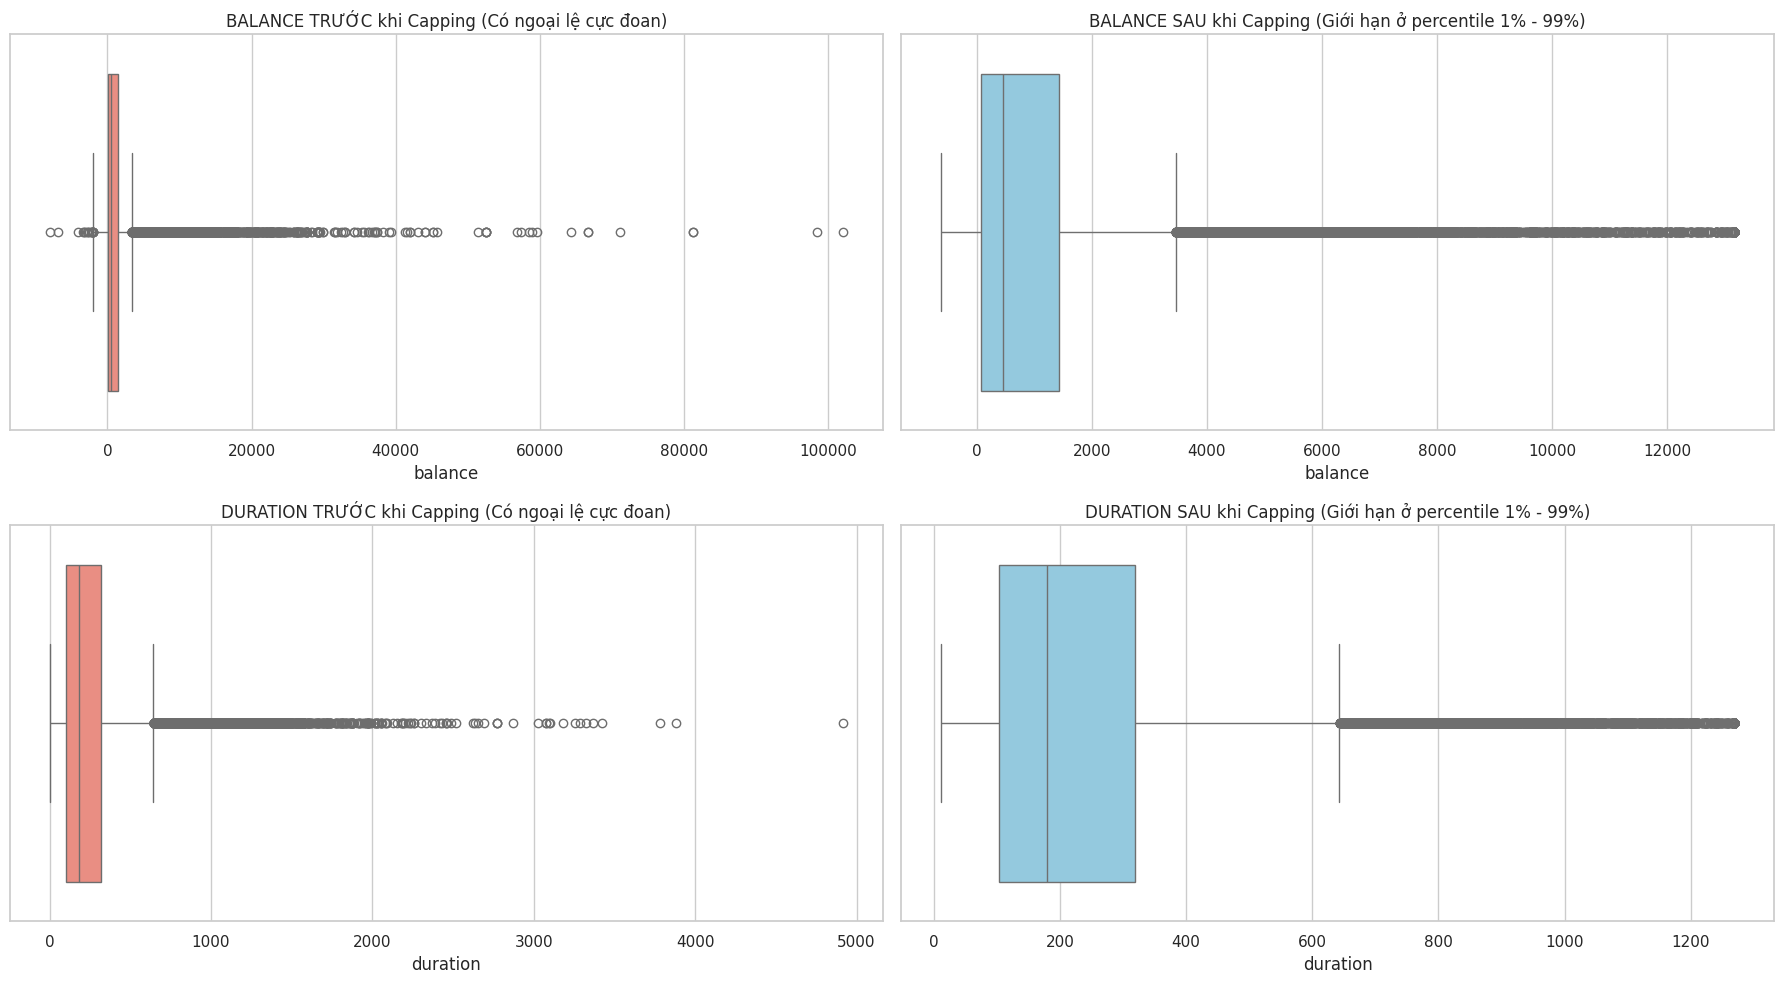

In [52]:
import matplotlib.pyplot as plt
import seaborn as sns

# Danh sách các biến đã thực hiện Capping
cols_to_compare = ['balance', 'duration']

fig, axes = plt.subplots(len(cols_to_compare), 2, figsize=(18, 10))

for i, col in enumerate(cols_to_compare):
    # Trước khi xử lý (dùng df gốc)
    sns.boxplot(x=df[col], ax=axes[i, 0], color='salmon')
    axes[i, 0].set_title(f'{col.upper()} TRƯỚC khi Capping (Có ngoại lệ cực đoan)')

    # Sau khi xử lý (dùng df_clean đã capping)
    sns.boxplot(x=df_clean[col], ax=axes[i, 1], color='skyblue')
    axes[i, 1].set_title(f'{col.upper()} SAU khi Capping (Giới hạn ở percentile 1% - 99%)')

plt.tight_layout()
plt.show()

: Capping(Winsorization) và Các Phương pháp Xử lý Outlier

Trong khoa học dữ liệu, **Outlier (Giá trị ngoại lệ)** là những quan sát nằm quá xa so với phần còn lại của dữ liệu. Việc xử lý chúng là bắt buộc vì các thuật toán như Logistic Regression hay SVM rất nhạy cảm với khoảng cách toán học.

 1. Capping (Winsorization) là gì?
**Winsorization** (đặt tên theo nhà thống kê Charles Winsor) là kỹ thuật thay thế các giá trị cực đoan bằng các giá trị ở ngưỡng phân vị xác định (thường là 1% và 99%).
*   **Cơ chế:** Nếu  chọn ngưỡng 99%, tất cả các giá trị lớn hơn phân vị thứ 99 sẽ được gán bằng giá trị của phân vị thứ 99 đó. Tương tự cho ngưỡng dưới 1%.
*   **Mục đích:** Giảm thiểu sự ảnh hưởng của các giá trị cực lớn (ví dụ: số dư tài khoản 100,000 Euro trong khi đa số là 1,000 Euro) mà không cần xóa bỏ dữ liệu.

2. So sánh các phương pháp phổ biến

| Phương pháp | Cách hoạt động | Ưu điểm | Nhược điểm |
| :--- | :--- | :--- | :--- |
| **Trimming (Xóa bỏ)** | Loại bỏ hoàn toàn dòng chứa outlier. | Dữ liệu sau xử lý rất "sạch" và đẹp. | **Mất thông tin.** Nếu có 10% outlier, bạn mất 10% khách hàng. Làm giảm tính đại diện của mẫu. |
| **Keeping (Giữ nguyên)** | Không làm gì cả. | Giữ toàn bộ tính nguyên bản của dữ liệu. | **Gây nhiễu nặng.** Mô hình bị chệch (bias), dẫn đến dự báo sai cho nhóm đa số. |
| **Capping (Winsorization)** | Ép giá trị về ngưỡng biên. | **Bảo toàn cỡ mẫu.** Giảm nhiễu hiệu quả mà vẫn giữ được thông tin rằng khách hàng đó thuộc nhóm "giá trị cao". | Làm thay đổi phân phối gốc của dữ liệu tại các điểm biên. |
| **Transformation (Log/Box-Cox)** | Dùng hàm toán học để nén khoảng cách. | Tốt cho dữ liệu có độ lệch (skewness) cao. | Khó giải thích ý nghĩa kinh tế trực tiếp của con số sau khi chuyển đổi. |

3. Tại sao chọn Capping cho biến `balance` và `duration`?
1.  **Tính chất nghiệp vụ:** Một khách hàng có số dư 200,000 Euro vẫn là một khách hàng thực, không phải dữ liệu lỗi. Xóa họ đi là sai lầm về mặt kinh doanh.
2.  **Độ ổn định của mô hình:** Bằng cách đưa giá trị 200,000 về ngưỡng 99% (giả sử là 15,000 Euro), thuật toán vẫn hiểu đây là khách hàng "giàu", nhưng khoảng cách 15,000 so với mức trung bình 1,000 sẽ không gây ra lỗi tính toán quá lớn như con số 200,000.
3.  **Duy trì tỷ lệ Class Imbalance:** Xóa dữ liệu có thể vô tình làm thay đổi tỷ lệ lớp `yes/no`, gây khó khăn thêm cho việc xử lý mất cân bằng lớp sau này.

 Xử lý giá trị thiếu (Missing values)
Kiểm tra lại xem còn giá trị null

In [21]:
print("Số lượng giá trị Null thực sự:")
print(df_clean.isnull().sum())

# Lưu lại file đã clean để dùng cho bước encoding tiếp theo
df_clean.to_csv('bank_data_cleaned.csv', index=False)
print("\nĐã lưu dữ liệu sạch vào file: bank_data_cleaned.csv")

Số lượng giá trị Null thực sự:
age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
previous     0
poutcome     0
y            0
dtype: int64

Đã lưu dữ liệu sạch vào file: bank_data_cleaned.csv


##8.Encoding và feature engineering: binary, one-hot, ordinal nếu phù hợp; kiểm tra data leakage

In [46]:
import pandas as pd
import numpy as np

# Tạo bản sao dữ liệu để xử lý
df_encoded = df_clean.copy()

# 1. Mã hóa biến mục tiêu 'y'
df_encoded['y'] = df_encoded['y'].map({'1': 0, '2': 1, 'no': 0, 'yes': 1})

# 2. Binary Encoding (0/1) cho các cột có 2 giá trị
binary_features = ['default', 'housing', 'loan']
for col in binary_features:
    df_encoded[col] = df_encoded[col].map({'no': 0, 'yes': 1})

# 3. Ordinal Encoding cho 'month' theo thứ tự thời gian chuẩn (1-12)
# Định nghĩa bản đồ ánh xạ để sắp xếp đúng logic lịch
month_map = {
    'jan': 1, 'feb': 2, 'mar': 3, 'apr': 4, 'may': 5, 'jun': 6,
    'jul': 7, 'aug': 8, 'sep': 9, 'oct': 10, 'nov': 11, 'dec': 12
}
df_encoded['month'] = df_encoded['month'].str.lower().map(month_map)

# 4. One-Hot Encoding cho các biến Nominal (định danh không thứ tự)
nominal_features = ['job', 'marital', 'education', 'contact', 'poutcome']
df_encoded = pd.get_dummies(df_encoded, columns=nominal_features, drop_first=True)

# Chuyển kiểu bool sang int cho các cột mới tạo từ dummies
new_cols = df_encoded.select_dtypes(include=['bool']).columns
df_encoded[new_cols] = df_encoded[new_cols].astype(int)

print("--- KẾT QUẢ ENCODING ---")
# Kiểm tra thứ tự tháng để xác nhận logic đúng
print(f"Thứ tự các tháng sau khi mã hóa thời gian: {sorted(df_encoded['month'].unique())}")
print(f"Kích thước tập dữ liệu mới: {df_encoded.shape}")
display(df_encoded[['month']].head())

--- KẾT QUẢ ENCODING ---
Thứ tự các tháng sau khi mã hóa thời gian: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12)]
Kích thước tập dữ liệu mới: (45211, 38)


,month
0,5
1,5
2,5
3,5
4,5


 Kiểm tra Data Leakage & Tính tương quan cuối cùng
 cần đảm bảo các biến sau khi encoding không có biến nào tương quan hoàn hảo với mục tiêu `y` (trừ chính nó) và kiểm tra lại sự phân bổ.


One-Hot Encoding: Dùng cho các biến không có thứ tự (như nghề nghiệp, tình trạng hôn nhân). Nó tạo ra các cột riêng biệt cho mỗi giá trị. Lệnh drop_first=True giúp tránh hiện tượng đa cộng tuyến (Dummy Variable Trap)

/tmp/ipykernel_1228/1458749295.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=corr_with_y.values, y=corr_with_y.index, palette='coolwarm')


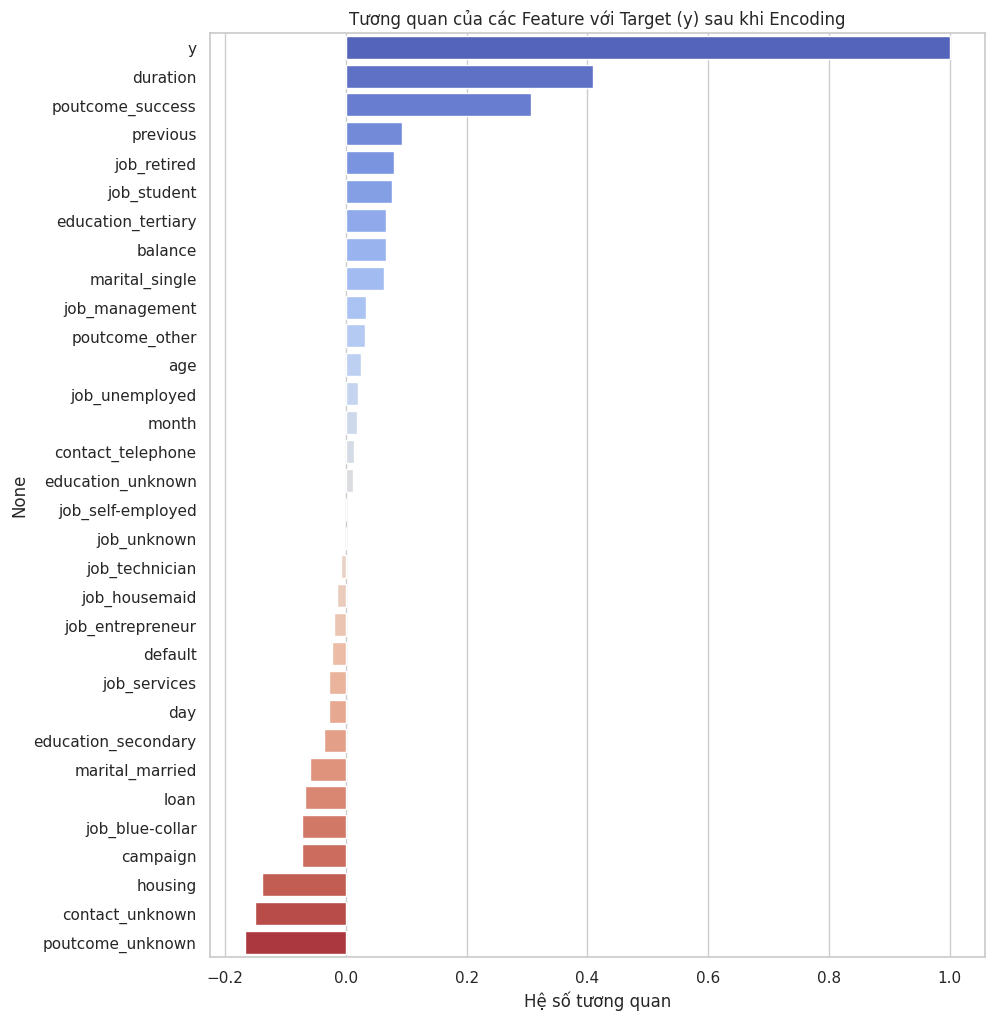

Dữ liệu hoàn toàn sạch, không có giá trị Null sau Encoding.


In [23]:
# Kiểm tra tương quan của các feature mới với biến mục tiêu y
plt.figure(figsize=(10, 12))
corr_with_y = df_encoded.corr()['y'].sort_values(ascending=False)

sns.barplot(x=corr_with_y.values, y=corr_with_y.index, palette='coolwarm')
plt.title('Tương quan của các Feature với Target (y) sau khi Encoding')
plt.xlabel('Hệ số tương quan')
plt.show()

# Kiểm tra giá trị Null phát sinh (nếu có)
if df_encoded.isnull().sum().sum() == 0:
    print("Dữ liệu hoàn toàn sạch, không có giá trị Null sau Encoding.")
else:
    print("Cảnh báo: Có giá trị Null phát sinh!")

##9.Feature selection: domain knowledge, correlation, statistical test, Mutual Information và loại feature không cần thiết

Calculating Mutual Information scores...


/tmp/ipykernel_1228/1026356624.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=mi_series.values, y=mi_series.index, palette='viridis')


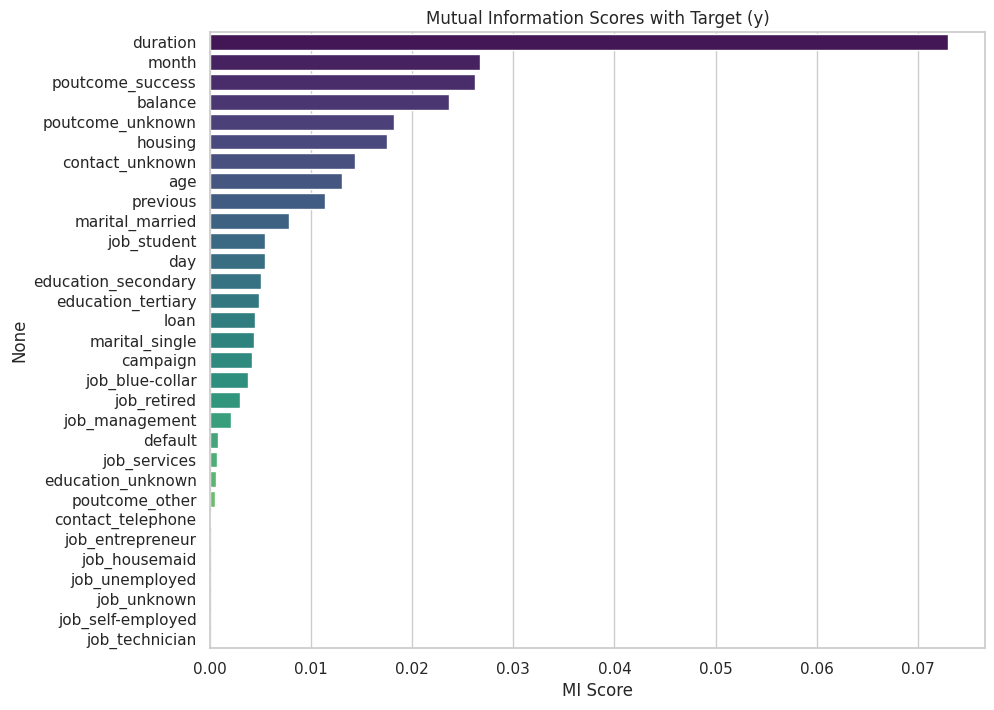

In [24]:
from sklearn.feature_selection import mutual_info_classif, RFE
from sklearn.ensemble import RandomForestClassifier
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare X and y
X = df_encoded.drop(columns=['y'])
y = df_encoded['y']

# 1. Mutual Information Analysis
print("Calculating Mutual Information scores...")
mi_scores = mutual_info_classif(X, y, random_state=42)
mi_series = pd.Series(mi_scores, name="MI Scores", index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x=mi_series.values, y=mi_series.index, palette='viridis')
plt.title("Mutual Information Scores with Target (y)")
plt.xlabel("MI Score")
plt.show()

##.10. Train/Validation/Test Split & Preprocessing Pipeline



In [55]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
import numpy as np
import pandas as pd

# Assuming df_encoded and mi_series (or selected_features) are already defined from previous cells
# If not, ensure the preceding cells (e.g., 0b7e0a16 and 13fb1b67) are run.

# Re-create feature_ranking and selected_features to ensure df_final is correctly constructed
# This code was originally in cell 476e18c8
feature_ranking = pd.DataFrame({
    'Feature': mi_series.index,
    'MI_Score': mi_series.values
})
selected_features = feature_ranking[feature_ranking['MI_Score'] > 0]['Feature'].tolist()

# Ensure y always included for downstream tasks
df_final = df_encoded[selected_features + ['y']]

# 1. Define X and y from the final selected features
X_final = df_final.drop(columns=['y'])
y_final = df_final['y']

# 2. Train-Test Split (Holdout 20% for final testing)
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X_final, y_final, test_size=0.2, random_state=42, stratify=y_final
)

# 3. Train-Validation Split (From the 80% remaining, take 25% for validation -> 20% of total)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.25, random_state=42, stratify=y_train_val
)

print(f"Train set size: {X_train.shape} ({len(y_train)/len(y_final)*100:.0f}%)")
print(f"Val set size:   {X_val.shape} ({len(y_val)/len(y_final)*100:.0f}%)")
print(f"Test set size:  {X_test.shape} ({len(y_test)/len(y_final)*100:.0f}%)")

Train set size: (27126, 25) (60%)
Val set size:   (9042, 25) (20%)
Test set size:  (9043, 25) (20%)


In [26]:
# 1. Tạo biến feature_ranking từ kết quả Mutual Information trước đó
import pandas as pd

feature_ranking = pd.DataFrame({
    'Feature': mi_series.index,
    'MI_Score': mi_series.values
})

# Lựa chọn các đặc trưng có điểm MI > 0 (ngưỡng cơ bản để loại bỏ nhiễu)
feature_ranking['Selected'] = feature_ranking['MI_Score'] > 0

# 2. Thực hiện lựa chọn (Final Selection)
selected_features = feature_ranking[feature_ranking['Selected'] == True]['Feature'].tolist()

# Đảm bảo y luôn được giữ lại cho các bước tiếp theo
df_final = df_encoded[selected_features + ['y']]

print(f"Final Dataset Shape: {df_final.shape}")
print(f"Số lượng đặc trưng được chọn: {len(selected_features)}")
print("Các đặc trưng hàng đầu:", selected_features[:10])

# Lưu tập dữ liệu cuối cùng
df_final.to_csv('bank_data_final.csv', index=False)
print("\n✅ Đã lưu dữ liệu final thành công vào file: bank_data_final.csv")
display(df_final.head())

Final Dataset Shape: (45211, 26)
Số lượng đặc trưng được chọn: 25
Các đặc trưng hàng đầu: ['duration', 'month', 'poutcome_success', 'balance', 'poutcome_unknown', 'housing', 'contact_unknown', 'age', 'previous', 'marital_married']

✅ Đã lưu dữ liệu final thành công vào file: bank_data_final.csv


,duration,month,poutcome_success,balance,poutcome_unknown,housing,contact_unknown,age,previous,marital_married,...,campaign,job_blue-collar,job_retired,job_management,default,job_services,education_unknown,poutcome_other,contact_telephone,y
0,261.0,5,0,2143.0,1,1,1,58.0,0.0,1,...,1.0,0,0,1,0,0,0,0,0,0
1,151.0,5,0,29.0,1,1,1,44.0,0.0,0,...,1.0,0,0,0,0,0,0,0,0,0
2,76.0,5,0,2.0,1,1,1,33.0,0.0,1,...,1.0,0,0,0,0,0,0,0,0,0
3,92.0,5,0,1506.0,1,1,1,47.0,0.0,1,...,1.0,1,0,0,0,0,1,0,0,0
4,198.0,5,0,1.0,1,0,1,33.0,0.0,0,...,1.0,0,0,0,0,0,1,0,0,0


In [27]:
# 4. Feature Scaling (Standardization)Chuẩn hóa dữ liệu
scaler = StandardScaler()

# Identify numerical columns in the final set to scale
# Note: Binary/One-hot encoded features don't necessarily need scaling, but it's safe for most models
num_cols_to_scale = X_train.select_dtypes(include=['float64', 'int64']).columns

X_train_scaled = X_train.copy()
X_val_scaled = X_val.copy()
X_test_scaled = X_test.copy()

X_train_scaled[num_cols_to_scale] = scaler.fit_transform(X_train[num_cols_to_scale])
X_val_scaled[num_cols_to_scale] = scaler.transform(X_val[num_cols_to_scale])
X_test_scaled[num_cols_to_scale] = scaler.transform(X_test[num_cols_to_scale])

print("Scaling completed using StandardScaler.")

Scaling completed using StandardScaler.


In [28]:
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)

print("--- Class Distribution After SMOTE ---")
unique, counts = np.unique(y_train_res, return_counts=True)
print(dict(zip(unique, counts)))
print(f"New training set size: {X_train_res.shape}")

--- Class Distribution After SMOTE ---
{np.int64(0): np.int64(23953), np.int64(1): np.int64(23953)}
New training set size: (47906, 25)


### Leakage & Model-Ready Confirmation


In [29]:
# Check for leakage: verify no feature is 'y'
leakage_check = X_train_res.columns.tolist()
if 'y' in leakage_check:
    print("CRITICAL: Target variable found in training features!")
else:
    print("Leakage Check Passed: Target variable is isolated.")

print("\nDataset is now MODEL-READY.")
print(f"Features: {X_train_res.columns.tolist()}")

Leakage Check Passed: Target variable is isolated.

Dataset is now MODEL-READY.
Features: ['duration', 'month', 'poutcome_success', 'balance', 'poutcome_unknown', 'housing', 'contact_unknown', 'age', 'previous', 'marital_married', 'job_student', 'day', 'education_secondary', 'education_tertiary', 'loan', 'marital_single', 'campaign', 'job_blue-collar', 'job_retired', 'job_management', 'default', 'job_services', 'education_unknown', 'poutcome_other', 'contact_telephone']


# IV. Modeling


## 11  Baseline: Logistic Regression,show các trọng số

xem xét các trọng số (coefficients) để hiểu cách mô hình Logistic Regression đánh giá các đặc trưng.

=== LOGISTIC REGRESSION CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

           0       0.97      0.84      0.90      7984
           1       0.39      0.79      0.52      1058

    accuracy                           0.83      9042
   macro avg       0.68      0.81      0.71      9042
weighted avg       0.90      0.83      0.85      9042



/tmp/ipykernel_1228/74366828.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Weight', y='Feature', data=df_weights, palette='RdBu_r')


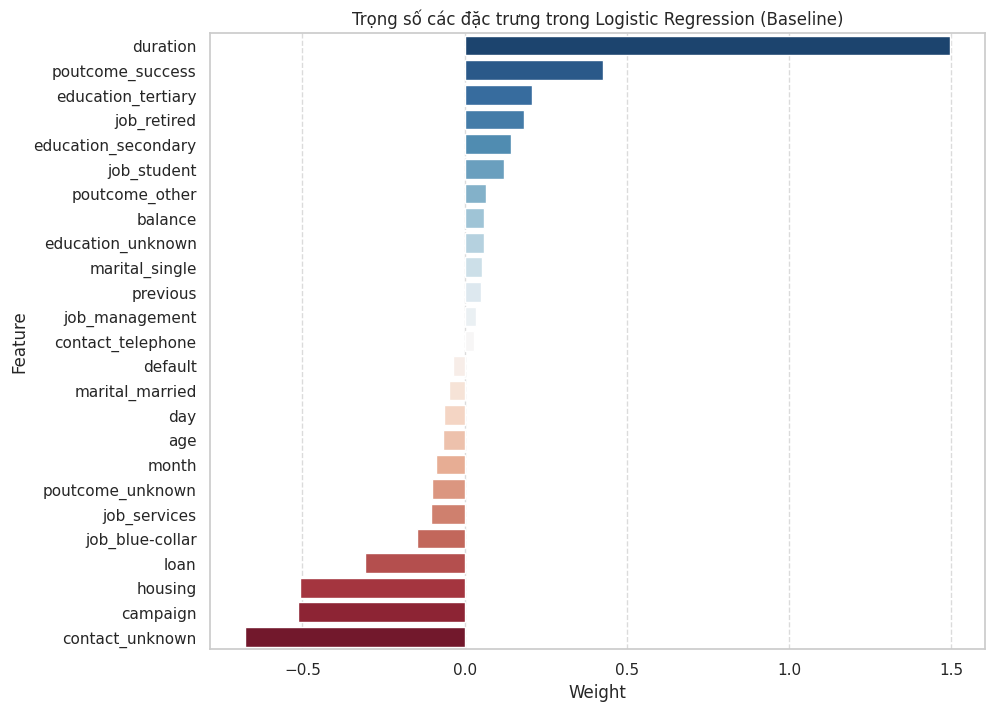

,Feature,Weight
0,duration,1.495378
2,poutcome_success,0.425497
13,education_tertiary,0.208795
18,job_retired,0.183828
12,education_secondary,0.141534
10,job_student,0.120777
23,poutcome_other,0.065767
3,balance,0.060968
22,education_unknown,0.058687
15,marital_single,0.053504


In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

# 1. Huấn luyện lại Baseline Logistic Regression (nếu cần) hoặc sử dụng từ biến models
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_res, y_train_res)

# 2. Dự đoán và hiển thị Report
y_pred_log = log_reg.predict(X_val_scaled)
print("=== LOGISTIC REGRESSION CLASSIFICATION REPORT ===")
print(classification_report(y_val, y_pred_log))

# 3. Lấy và hiển thị trọng số (Coefficients)
feature_names = X_train_res.columns
weights = log_reg.coef_[0]

df_weights = pd.DataFrame({
    'Feature': feature_names,
    'Weight': weights
}).sort_values(by='Weight', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x='Weight', y='Feature', data=df_weights, palette='RdBu_r')
plt.title('Trọng số các đặc trưng trong Logistic Regression (Baseline)')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

display(df_weights)

 Mô hình xem xét tất cả các biến cùng một lúc. Trọng số (Weight) cho biết sức ảnh hưởng của một biến sau khi đã loại bỏ ảnh hưởng của các biến khác.

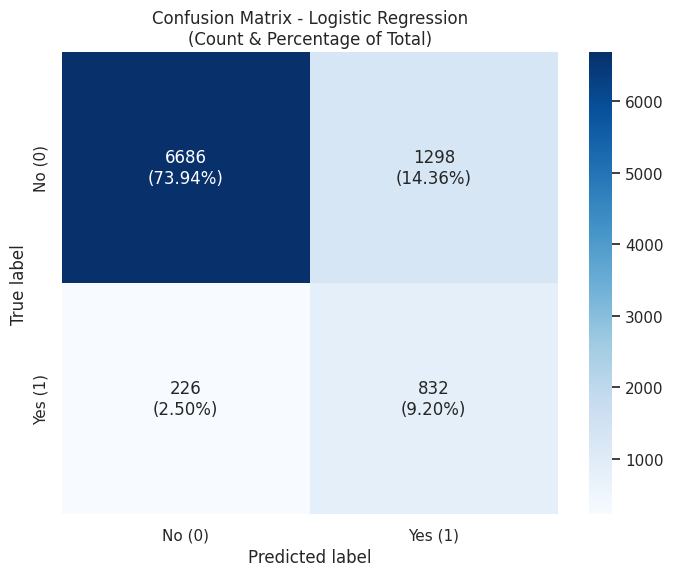

In [56]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

# 4. Trực quan hóa Confusion Matrix với số lượng và tỷ lệ phần trăm
cm = confusion_matrix(y_val, y_pred_log)

# Tính toán tỷ lệ phần trăm trên tổng số mẫu
cm_perc = cm.astype('float') / cm.sum() * 100

# Tạo nhãn kết hợp số lượng và phần trăm
labels = [f"{v}\n({p:.2f}%)" for v, p in zip(cm.flatten(), cm_perc.flatten())]
labels = np.array(labels).reshape(2, 2)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=labels, fmt="", cmap='Blues', ax=ax,
            xticklabels=['No (0)', 'Yes (1)'],
            yticklabels=['No (0)', 'Yes (1)'])

plt.title('Confusion Matrix - Logistic Regression\n(Count & Percentage of Total)')
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.grid(False)
plt.show()

## 12.AUC, phân tích mối quan hệ top 5 featrues và target
- biến categorical
- biến numerical -> bin theo quantiles (10 bins)
 Đánh giá ROC-AUC và Phân tích Đặc trưng cho Logistic Regression


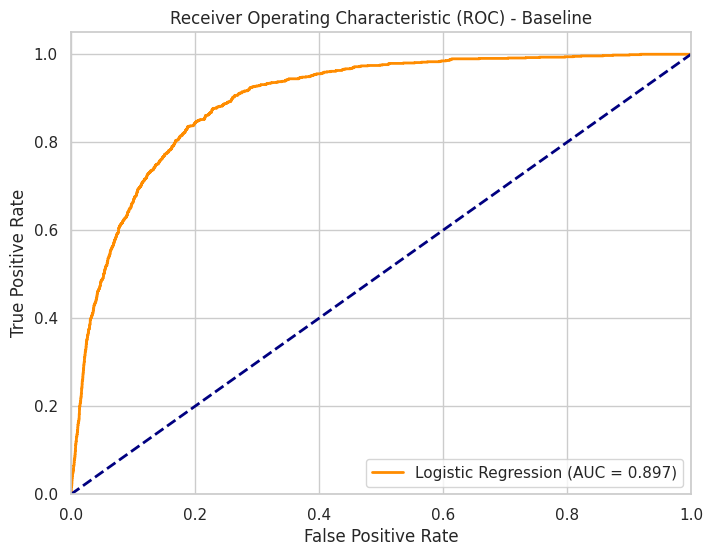

In [33]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# 1. Tính xác suất dự đoán (probabilities) cho tập validation
# log_reg đã được train ở cell 6c78c42e
y_proba_val = log_reg.predict_proba(X_val_scaled)[:, 1]

# 2. Vẽ đường cong ROC cho Logistic Regression
fpr_log, tpr_log, _ = roc_curve(y_val, y_proba_val)
roc_auc_log = auc(fpr_log, tpr_log)

plt.figure(figsize=(8, 6))
plt.plot(fpr_log, tpr_log, color='darkorange', lw=2, label=f'Logistic Regression (AUC = {roc_auc_log:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) - Baseline')
plt.legend(loc="lower right")
plt.show()

Phân tích các biến: ['duration', 'contact', 'campaign', 'housing', 'poutcome']


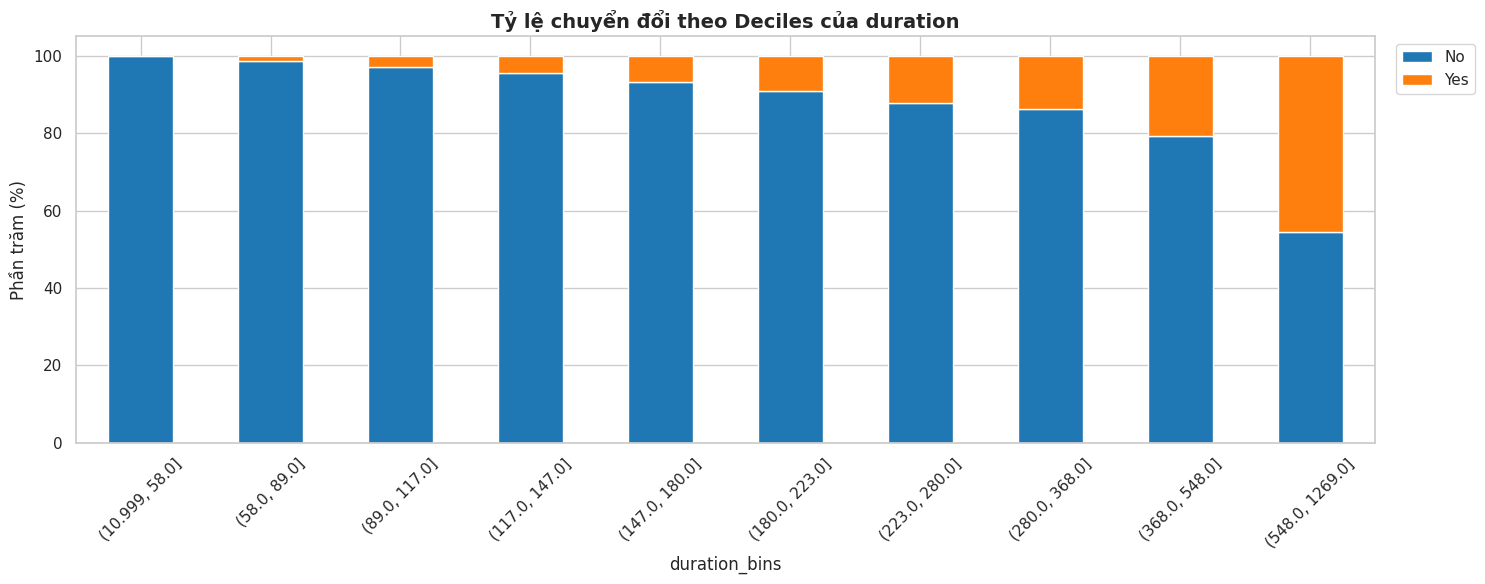

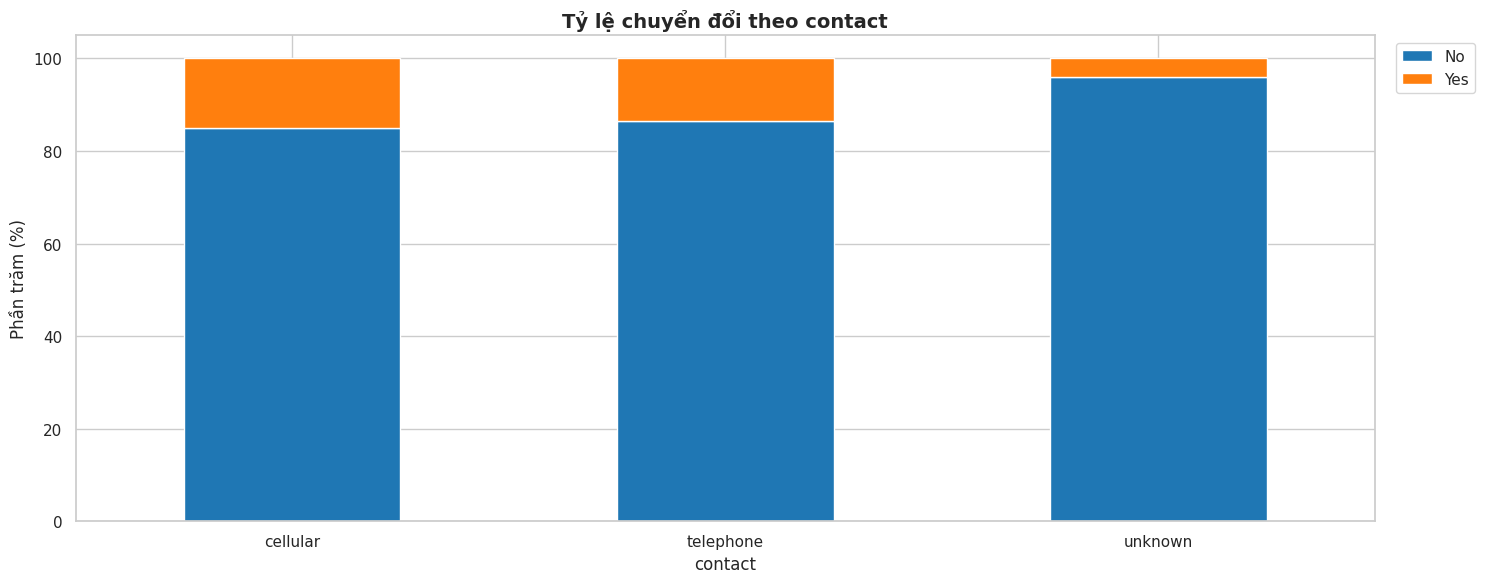

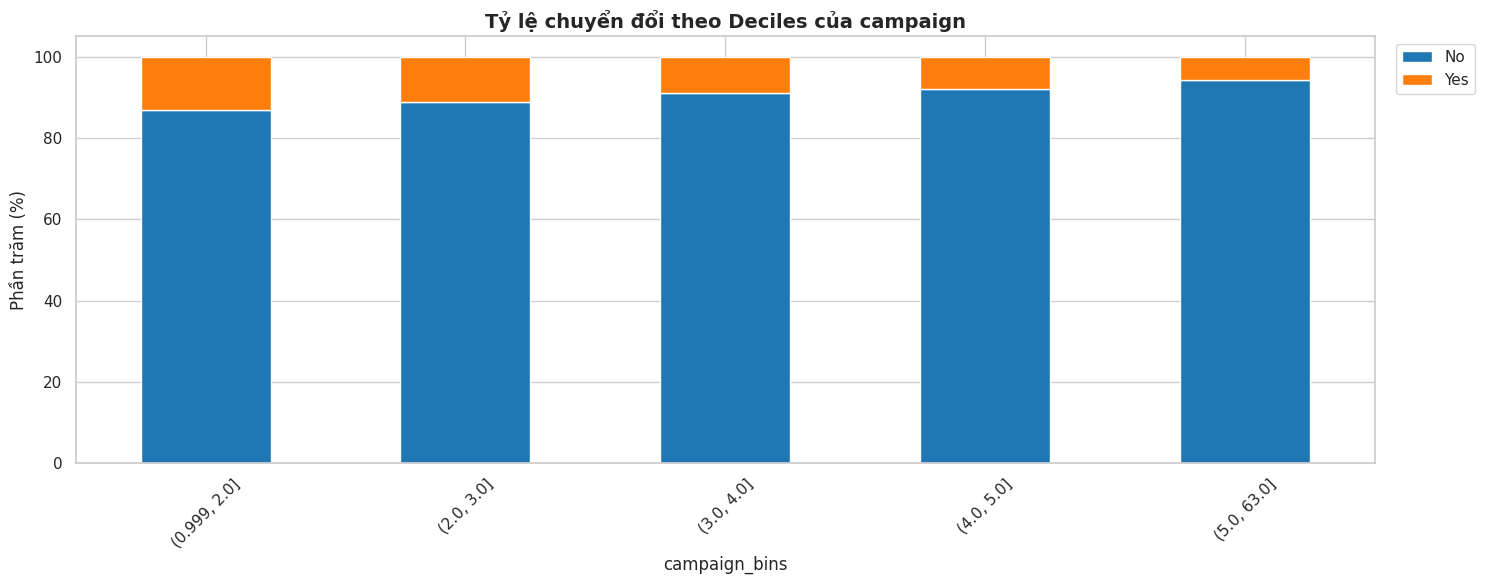

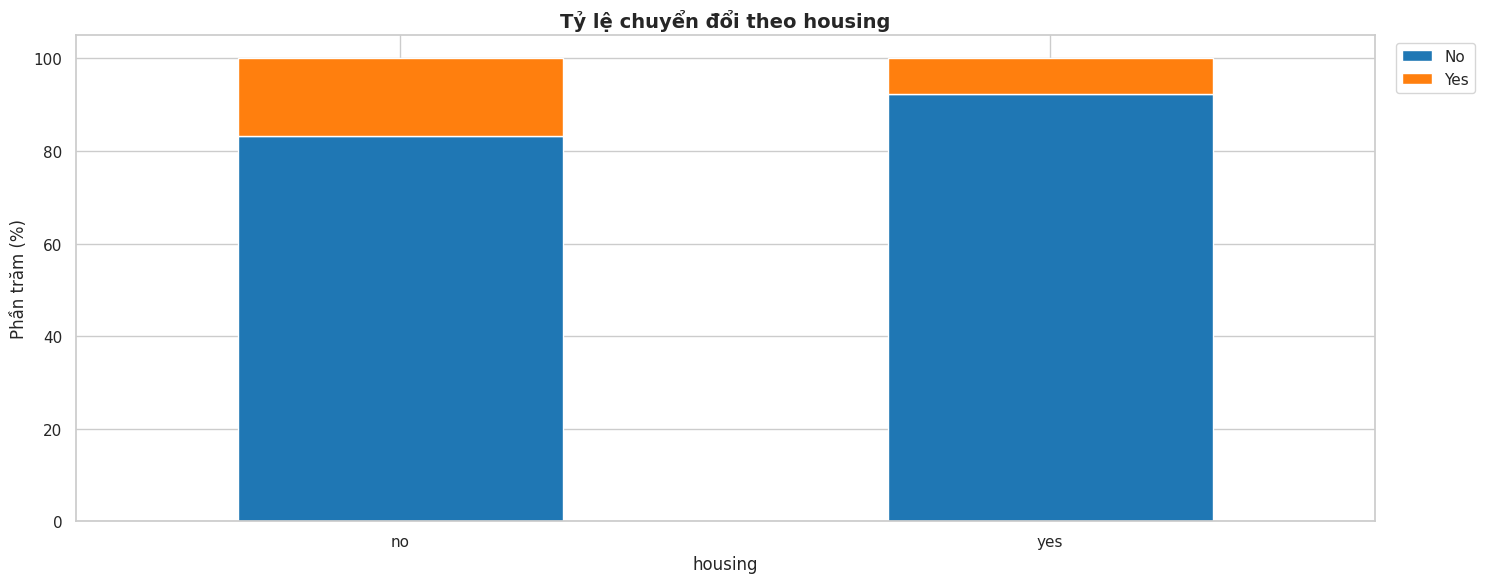

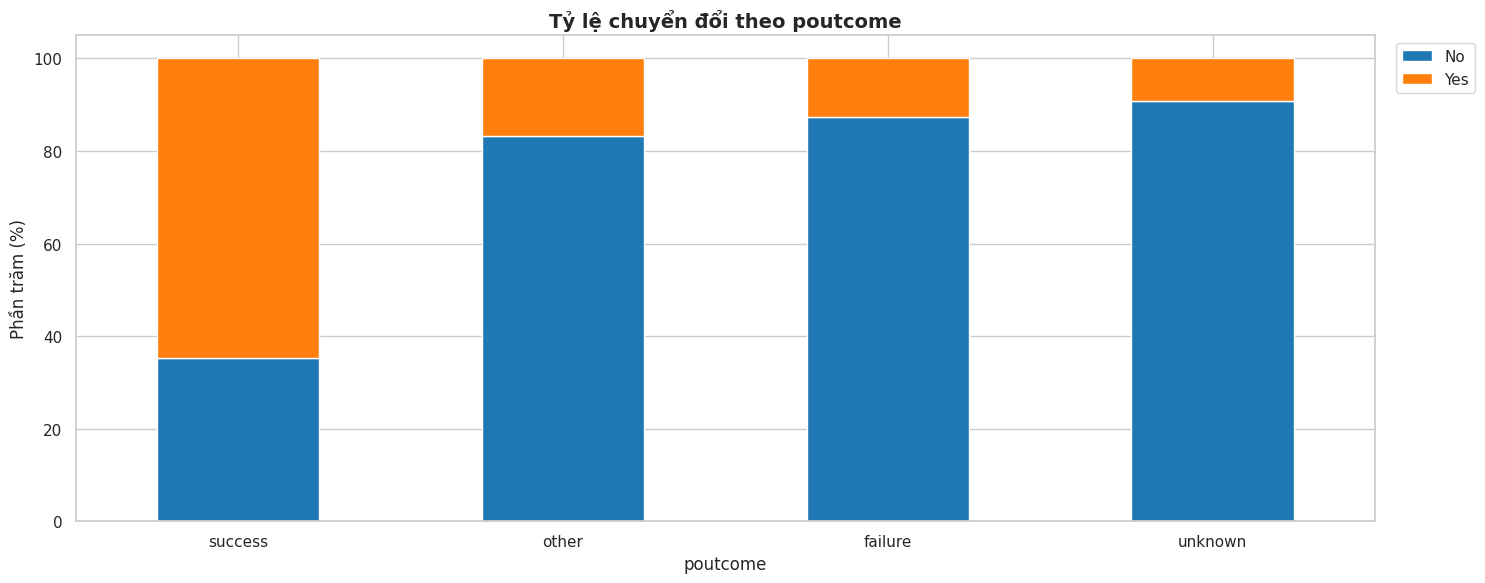

In [36]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Xác định top 5 features từ df_weights (dựa trên trị tuyệt đối của trọng số)
df_weights['Abs_Weight'] = df_weights['Weight'].abs()
top_5_log_encoded = df_weights.sort_values(by='Abs_Weight', ascending=False).head(5)['Feature'].tolist()

# Ánh xạ về tên biến gốc (trước khi encoding)
mapping = {
    'duration': 'duration',
    'contact_unknown': 'contact',
    'campaign': 'campaign',
    'housing': 'housing',
    'poutcome_success': 'poutcome'
}
top_5_features = [mapping[f] for f in top_5_log_encoded if f in mapping]

print(f"Phân tích các biến: {top_5_features}")

for col in top_5_features:
    # Tăng chiều ngang figsize để lấp đầy không gian
    plt.figure(figsize=(15, 6))

    if df_clean[col].dtype in ['float64', 'int64']:
        # Đối với biến số: Chia làm 10 bins theo Quantiles
        try:
            df_clean[f'{col}_bins'] = pd.qcut(df_clean[col], q=10, duplicates='drop')
        except ValueError:
            df_clean[f'{col}_bins'] = pd.qcut(df_clean[col].rank(method='first'), q=10)

        # Tính tỷ lệ chuyển đổi (y=2 là Yes)
        temp = df_clean.groupby(f'{col}_bins', observed=False)['y'].value_counts(normalize=True).unstack() * 100
        temp = temp.rename(columns={'1': 'No', '2': 'Yes'})

        ax = temp.plot(kind='bar', stacked=True, color=['#1f77b4', '#ff7f0e'], ax=plt.gca())
        plt.title(f'Tỷ lệ chuyển đổi theo Deciles của {col}', fontsize=14, fontweight='bold')
        plt.ylabel('Phần trăm (%)')
        plt.xticks(rotation=45)
    else:
        # Đối với biến phân loại
        temp = df_clean.groupby(col, observed=False)['y'].value_counts(normalize=True).unstack() * 100
        temp = temp.rename(columns={'1': 'No', '2': 'Yes'})

        ax = temp.sort_values(by='Yes', ascending=False).plot(kind='bar', stacked=True, color=['#1f77b4', '#ff7f0e'], ax=plt.gca())
        plt.title(f'Tỷ lệ chuyển đổi theo {col}', fontsize=14, fontweight='bold')
        plt.ylabel('Phần trăm (%)')
        plt.xticks(rotation=0)

    plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left')
    plt.tight_layout()
    plt.show()